# Описание проекта №2

В рамках проекта №2 требуется реализовать автоматизированный пайплайн для прогнозирования значений временного ряда на следующий день.
Ряды представляют собой срезы притоков, оттоков и сальдо показателя, связанного с потоками ликвидности Банка, в обозначенные моменты времени.
Прогноз требуется строить для значения сальдо (разницы между притоками и оттоками).
Заказчик модели высказал пожелание, чтобы ошибка прогноза составляла не более 0.42 в абсолютном значении.


Требования к модели:
- Выбор оптимизируемой метрики должен быть основан на потребностях бизнеса.
- Модель может использовать внешние факторы (см. подсказки).
- Модель должна иметь модуль отбора признаков. Метод отбора должен быть более стабильным относительно альтернатив. Сравнение должно быть проведено минимум с одним методом из каждой категории: встроенные, оберточные и фильтрационные. При этом как минимум одна из альтернатив должна исследовать нелинейную зависимость.
- Модель должна автоматически подбирать гиперпараметры, оптимизируя целевую метрику.
- Для модели должна быть подобрана частота калибровки, если модель калибруется долго, и проверена ее достаточность.
- Блоки должны быть подписаны и кратко описаны (чем руководствовались при реализации, как работает).
- Модель должна автоматически дообучаться. Все модули должны работать без ручных корректировок. Выбор периода для дообучения должен быть обоснован.
- В модели должен быть модуль выявления разладки для подачи сигнала о возможной необходимости переключения на ручное управление процессом/внеплановое дообучение.
- При подборе модели обязательно нужно исследовать возможность применения авторегрессионных моделей.

Подсказки:
- Можно использовать факторы, сконструированные из таргета (лаги, средние и т.п.).
- Могут помочь макроэкономические факторы.
- Могут помочь даты налоговых дней.

Описание бизнес-процесса:
1. Прогнозная величина позволяет установить сальдо поступлений и списаний за день.
2. На основании прогноза позиционер (управляет ликвидностью) принимает решение о выделении средств на размещение на рынке деривативов для получения дополнительной маржи (доходность считать примерно ключ + 0.5%).
3. В случае, если на конец дня образуется профицит ликвидности, его можно разместить в ЦБ по overnight-ставке, равной ключу - 0.9%.
4. В случае, если на конец дня образуется дефицит ликвидности, его можно покрыть за счет займа по overnight-ставке, равной ключ + 1%.

# План решения проекта

Проект стоит строить как полноценный автоматизированный ML-пайплайн, но начинать не с модели, а с бизнес-логики ошибки.

1. Разобраться с бизнес-целью.
   Нужно формализовать, какая ошибка прогноза хуже для бизнеса: недооценить сальдо и оставить лишнюю ликвидность менее доходному размещению или переоценить сальдо и столкнуться с необходимостью покрывать дефицит займом. Из этого выбирается оптимизируемая метрика.

2. Подготовить данные.
   Необходимо проверить даты, пропуски, дубликаты, частоту ряда, выбросы, структуру притоков, оттоков и сальдо, а также возможные календарные эффекты.

3. Сделать базовые модели.
   До сложных моделей нужно построить простые бейзлайны: прогноз как вчера, скользящее среднее, сезонный наивный прогноз и простую авторегрессию. Это позволит оценить, дает ли более сложная модель реальное улучшение.

4. Сконструировать признаки.
   Можно использовать лаги сальдо, притоков и оттоков, скользящие средние, скользящие стандартные отклонения, изменения день-к-дню, календарные признаки, признаки налоговых дней и доступные макроэкономические факторы. Все признаки должны быть доступны на момент построения прогноза.

5. Исследовать авторегрессионные модели.
   Нужно отдельно проверить возможность применения ARIMA/SARIMA/SARIMAX или регрессии на лагах и сравнить их качество с ML-моделями.

6. Реализовать отбор признаков.
   Нужно сравнить методы из трех категорий: фильтрационные, встроенные и оберточные. Как минимум одна альтернатива должна учитывать нелинейные зависимости. Итоговый метод отбора должен быть выбран с учетом стабильности на временных срезах.

7. Подобрать модель и гиперпараметры.
   Кандидатами могут быть линейные модели, Random Forest/ExtraTrees, градиентный бустинг и авторегрессионные модели. Подбор гиперпараметров нужно проводить через time-series cross-validation с оптимизацией целевой метрики.

8. Подобрать частоту калибровки и дообучения.
   Нужно проверить разные режимы: обучение на всей истории, скользящее окно, ежедневное дообучение, еженедельное или ежемесячное дообучение. Если калибровка модели занимает много времени, нужно выбрать минимальную достаточную частоту.

9. Реализовать автоматическое дообучение.
   Пайплайн должен сам загружать новые данные, пересчитывать признаки, проверять качество, при необходимости дообучать модель и сохранять новую версию. Период для дообучения должен быть обоснован экспериментально.

10. Добавить модуль выявления разладки.
    Нужно отслеживать ошибку прогноза и сдвиги в распределении признаков, чтобы подавать сигнал о возможной необходимости внепланового дообучения или ручного управления процессом.

11. Собрать финальный автоматизированный пайплайн.
    Итоговое решение должно объединять загрузку данных, генерацию признаков, отбор признаков, прогнозирование, проверку качества, дообучение и модуль разладки без ручных корректировок.


# Решение проекта

## Определение оптимизируемой метрики

Для того, чтобы понять какую именно метрику нам надо оптимизировать, давайте посмотрим на потребности бизнеса и какие вообще сценарии могут быть.

В управлении ликвидностью бизнесу обычно нужно одновременно решить две задачи:
1. Всегда выполнять платежи и обязательства: У банка не должно быть ситуации “не хватило денег на расчет”. Это операционный и репутационный риск. Поэтому часть ликвидности всегда держат свободной.
2. Не держать слишком много денег без дела: Свободная ликвидность сама по себе почти ничего не зарабатывает или зарабатывает меньше, чем могла бы. Если понятно, что часть денег сегодня не понадобится, ее можно разместить в доходный инструмент.

По сути это сводится к тому, чтобы выполнить все свои обязательства, с минимальными издержками или же максимальной прибылью

### Возможные сценарии

Обозначим:
- `y_pred` — прогнозное сальдо;
- `y_true` — фактическое сальдо.

Если прогнозное сальдо положительное, позиционер может заранее выделить часть ликвидности на размещение в более доходный инструмент. После завершения дня фактическое сальдо показывает, насколько это решение было корректным.

1. Прогноз положительный, факт положительный

`y_pred > 0`, `y_true > 0`

Мы ожидали профицит, и он действительно случился. Внутри этого сценария есть два варианта:
- если `y_pred < y_true`, мы занизили профицит: заранее разместили меньше, чем могли, а остаток ушел в менее доходное размещение;
- если `y_pred > y_true`, мы завысили профицит: заранее выделили больше ликвидности, чем фактически было свободно, поэтому может возникнуть необходимость покрывать нехватку займом.

2. Прогноз положительный, факт отрицательный

`y_pred > 0`, `y_true < 0`

Мы ожидали профицит и могли заранее выделить средства на размещение, но по факту получили дефицит. Это рискованный сценарий завышения прогноза: бизнес рассчитывал на свободную ликвидность, а в конце дня столкнулся с нехваткой средств.

3. Прогноз отрицательный, факт положительный

`y_pred < 0`, `y_true > 0`

Мы ожидали дефицит, поэтому не выделяли средства на более доходное размещение. По факту возник профицит, который можно разместить только в конце дня. Это сценарий занижения прогноза: прямого дефицита нет, но появляется упущенная доходность.

4. Прогноз отрицательный, факт отрицательный

`y_pred < 0`, `y_true < 0`

Мы ожидали дефицит, и он действительно случился. Если фактический дефицит оказался сильнее прогноза, бизнесу нужно покрыть большую нехватку средств, чем ожидалось. Если фактический дефицит оказался слабее прогноза, решение было слишком осторожным, но свободной ликвидности для размещения все равно не возникло.

Таким образом, ошибка прогноза влияет не только на точность модели, но и на финансовый результат: завышение может привести к необходимости занимать средства, а занижение — к упущенной доходности от более выгодного размещения.

### Постановка ML-задачи и выбор метрик

Так как основная цель бизнеса - заработать, целевая переменная модели — `Balance`, то есть сальдо притоков и оттоков на следующий день. `Income`, `Outcome`, календарные признаки, лаги, скользящие статистики и другие доступные факторы могут использоваться как признаки для прогноза.

Основная бизнес-метрика для выбора лучшей модели — `business_loss`:

`business_loss = ideal_profit - model_profit`

где:
- `model_profit` — финансовый результат стратегии управления ликвидностью, построенной на прогнозе модели;
- `ideal_profit` — финансовый результат стратегии при идеальном прогнозе фактического `Balance`.

Эта метрика показывает упущенную прибыль относительно идеального решения. Чем меньше `business_loss`, тем лучше модель с точки зрения бизнес-цели.

Также `model_profit` смотрим, чтобы интерпретировать результат в деньгах:

`model_profit = доход от размещения на рынке деривативов + доход от размещения профицита в ЦБ - стоимость займа при дефиците`

`model_profit` нужен для понимания того, сколько стратегия могла бы заработать, но для сравнения моделей удобнее использовать `business_loss`, потому что его нужно минимизировать.

В качестве технических метрик качества прогноза используем:
- `MAE` — средняя абсолютная ошибка;
- `RMSE` — корень из средней квадратичной ошибки;
- доля прогнозов, для которых `|y_true - y_pred| <= 0.42`.

Главная метрика выбора модели — `business_loss`, так как она отражает потребности бизнеса. Технические метрики используются как контроль качества, чтобы финансово выгодная модель не достигала результата за счет неприемлемого ухудшения точности прогноза.

## Базовая проверка / Анализ данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("Project 1_2024.xlsx")

df = pd.read_excel(DATA_PATH, sheet_name=0)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

print("1. Структура данных")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum().values,
    "null_count": df.isna().sum().values,
}))
display(df.head())
display(df.tail())


1. Структура данных
Размер датасета: 1543 строк, 4 колонок


,column,dtype,non_null,null_count
Date,Date,datetime64[ns],1543,0
Income,Income,float64,1543,0
Outcome,Outcome,float64,1543,0
Balance,Balance,float64,1543,0


,Date,Income,Outcome,Balance
0,2017-01-09,1.343028,1.487865,-0.155904
1,2017-01-10,1.068610,1.194182,-0.125572
2,2017-01-11,0.944429,0.936663,0.007767
3,2017-01-12,1.672202,0.875379,0.800391
4,2017-01-13,0.955924,0.975645,-0.019721


,Date,Income,Outcome,Balance
1538,2021-03-27,0.000000,0.000000,0.000000
1539,2021-03-28,0.000000,0.000000,0.000000
1540,2021-03-29,2.356883,3.370738,-1.017679
1541,2021-03-30,2.317382,2.567554,-0.259687
1542,2021-03-31,2.528054,2.528054,-0.004878


In [2]:
print("2. Даты и частота ряда")

print(f"Минимальная дата: {df['Date'].min()}")
print(f"Максимальная дата: {df['Date'].max()}")
print(f"Количество уникальных дат: {df['Date'].nunique()}")

date_diffs = df["Date"].diff().dropna()
print("Распределение интервалов между соседними датами:")
display(date_diffs.value_counts().sort_index().rename_axis("date_diff").reset_index(name="count"))

full_calendar = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
missing_calendar_dates = full_calendar.difference(df["Date"].dropna())
print(f"Пропущено календарных дат: {len(missing_calendar_dates)}")
if len(missing_calendar_dates) > 0:
    display(pd.Series(missing_calendar_dates, name="missing_calendar_dates").head(20))

business_calendar = pd.date_range(df["Date"].min(), df["Date"].max(), freq="B")
missing_business_dates = business_calendar.difference(df["Date"].dropna())
print(f"Пропущено рабочих дат по стандартному календарю Mon-Fri: {len(missing_business_dates)}")
if len(missing_business_dates) > 0:
    display(pd.Series(missing_business_dates, name="missing_business_dates").head(20))


2. Даты и частота ряда
Минимальная дата: 2017-01-09 00:00:00
Максимальная дата: 2021-03-31 00:00:00
Количество уникальных дат: 1543
Распределение интервалов между соседними датами:


,date_diff,count
0,1 days,1542


Пропущено календарных дат: 0
Пропущено рабочих дат по стандартному календарю Mon-Fri: 0


In [3]:
print("3. Пропуски")

missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean(),
})
display(missing_report)


3. Пропуски


,missing_count,missing_share
Date,0,0.0
Income,0,0.0
Outcome,0,0.0
Balance,0,0.0


In [4]:
print("4. Проверка формулы Balance = Income - Outcome")

balance_diff = df["Balance"] - (df["Income"] - df["Outcome"])
balance_check = balance_diff.abs().describe().to_frame(name="abs_balance_diff")
display(balance_check)
print(f"Максимальное абсолютное расхождение: {balance_diff.abs().max():.10f}")

tolerance = 1e-8
balance_mismatch = df.loc[balance_diff.abs() > tolerance, ["Date", "Income", "Outcome", "Balance"]].copy()
balance_mismatch["expected_balance"] = balance_mismatch["Income"] - balance_mismatch["Outcome"]
balance_mismatch["balance_diff"] = balance_mismatch["Balance"] - balance_mismatch["expected_balance"]
print(f"Количество строк с расхождением больше {tolerance}: {len(balance_mismatch)}")
if len(balance_mismatch) > 0:
    display(balance_mismatch.head(20))


4. Проверка формулы Balance = Income - Outcome


,abs_balance_diff
count,1543.000000
mean,0.002281
std,0.002984
min,0.000000
25%,0.000000
50%,0.000705
75%,0.004074
max,0.013167


Максимальное абсолютное расхождение: 0.0131669455
Количество строк с расхождением больше 1e-08: 863


,Date,Income,Outcome,Balance,expected_balance,balance_diff
0,2017-01-09,1.343028,1.487865,-0.155904,-0.144836,-0.011067
3,2017-01-12,1.672202,0.875379,0.800391,0.796823,0.003568
8,2017-01-17,0.896334,1.448364,-0.548519,-0.552030,0.003512
18,2017-01-27,1.196396,1.395696,-0.198483,-0.199300,0.000817
21,2017-01-30,1.303732,1.461531,-0.154703,-0.157799,0.003096
31,2017-02-09,1.501032,1.071717,0.434681,0.429315,0.005366
44,2017-02-22,1.435197,1.422030,0.022756,0.013167,0.009589
49,2017-02-27,1.764371,1.882873,-0.118862,-0.118503,-0.000360
50,2017-02-28,1.501032,1.711703,-0.211128,-0.210671,-0.000457
59,2017-03-09,1.356195,1.063539,0.298185,0.292656,0.005529


In [5]:
print("5. Дубликаты и подозрительные значения")

duplicate_dates = df[df.duplicated("Date", keep=False)].sort_values("Date")
print(f"Количество строк с дублирующимися датами: {len(duplicate_dates)}")
if len(duplicate_dates) > 0:
    display(duplicate_dates)

numeric_cols = ["Income", "Outcome", "Balance"]
invalid_numeric = pd.DataFrame({
    "nan_count": df[numeric_cols].isna().sum(),
    "inf_count": np.isinf(df[numeric_cols]).sum(),
    "zero_count": (df[numeric_cols] == 0).sum(),
    "negative_count": (df[numeric_cols] < 0).sum(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
})
display(invalid_numeric)

for column in numeric_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: потенциальных выбросов по правилу 1.5*IQR — {len(outliers)}")
    if len(outliers) > 0:
        display(outliers[["Date", column]].head(10))


5. Дубликаты и подозрительные значения
Количество строк с дублирующимися датами: 0


,nan_count,inf_count,zero_count,negative_count,min,max
Income,0,0,451,0,0.000000,5.108775
Outcome,0,0,441,0,0.000000,5.003439
Balance,0,0,431,644,-2.514887,1.408863


Income: потенциальных выбросов по правилу 1.5*IQR — 3


,Date,Income
1449,2020-12-28,5.108775
1450,2020-12-29,4.292424
1451,2020-12-30,4.489928


Outcome: потенциальных выбросов по правилу 1.5*IQR — 2


,Date,Outcome
1449,2020-12-28,5.003439
1537,2021-03-26,4.687433


Balance: потенциальных выбросов по правилу 1.5*IQR — 219


,Date,Balance
3,2017-01-12,0.800391
8,2017-01-17,-0.548519
31,2017-02-09,0.434681
64,2017-03-14,0.358358
77,2017-03-27,1.343028
78,2017-03-28,-1.244018
79,2017-03-29,0.331271
109,2017-04-28,-0.432262
134,2017-05-23,-0.890454
137,2017-05-26,0.698869


В целом выбросы не выглядят ужасающими, они в полне себе нормальны, за исключением некоторых выбросов в `Balance`, но кажется с этим можно работать.

При этом вызывает смущение большое количество несовпадений в `Balance`, если единицы приходов и расходов считаются например в млн/млрд, то недочеты могут быть либо порядка 11к либо порядка 11млн.

В любом случае будем использовать `Balance` как основной таргет, а не пытаться перепредсказать его по `Income` - `Outcome` ведь за этим может храниться логика, которой мы не знаем, но модель может ее выучить.

Далее давайте посмотрим на
- распределения `Income`, `Outcome`, `Balance`;
- временную динамику и скользящие статистики;
- календарные эффекты: день недели, месяц, начало и конец месяца.


6. Распределения


,count,mean,median,std,min,max,skew
Income,1543.0,1.084909,1.329861,0.838651,0.000000,5.108775,0.025380
Outcome,1543.0,1.133737,1.329861,0.901904,0.000000,5.003439,0.166426
Balance,1543.0,-0.048860,0.000000,0.292011,-2.514887,1.408863,-1.239365


,0.01,0.05,0.25,0.50,0.75,0.95,0.99
Income,0.000000,0.000000,0.000000,1.329861,1.672202,2.238381,2.925169
Outcome,0.000000,0.000000,0.000000,1.329861,1.738037,2.501720,3.303587
Balance,-0.990036,-0.542577,-0.142705,0.000000,0.037721,0.337483,0.709368


,balance_sign,count,share
0,negative,644,0.417369
1,positive,468,0.303305
2,zero,431,0.279326


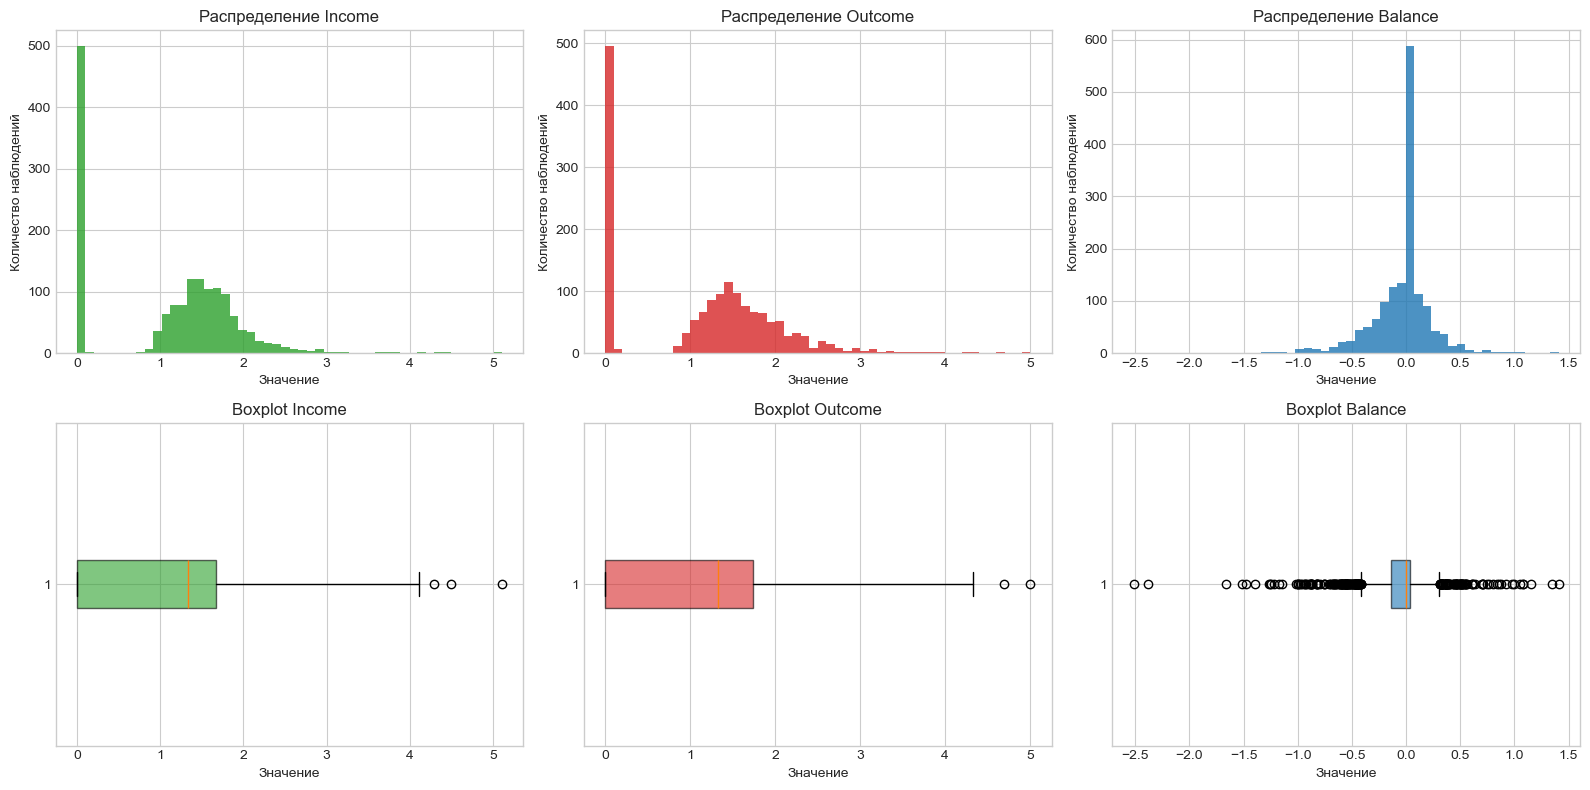

In [6]:
# Продолжаем работать с df, подготовленным в предыдущем блоке.
numeric_cols = ["Income", "Outcome", "Balance"]

print("6. Распределения")
distribution_summary = df[numeric_cols].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T
quantiles = df[numeric_cols].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(distribution_summary)
display(quantiles)

balance_sign = pd.Series(
    np.select(
        [df["Balance"] > 0, df["Balance"] < 0],
        ["positive", "negative"],
        default="zero",
    ),
    name="balance_sign",
)
balance_sign_report = (
    balance_sign.value_counts()
    .rename_axis("balance_sign")
    .reset_index(name="count")
)
balance_sign_report["share"] = balance_sign_report["count"] / len(balance_sign)
display(balance_sign_report)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, column, color in zip(axes[0], numeric_cols, ["tab:green", "tab:red", "tab:blue"]):
    ax.hist(df[column].dropna(), bins=50, color=color, alpha=0.8)
    ax.set_title(f"Распределение {column}")
    ax.set_xlabel("Значение")
    ax.set_ylabel("Количество наблюдений")

for ax, column, color in zip(axes[1], numeric_cols, ["tab:green", "tab:red", "tab:blue"]):
    ax.boxplot(df[column].dropna(), vert=False, patch_artist=True, boxprops={"facecolor": color, "alpha": 0.6})
    ax.set_title(f"Boxplot {column}")
    ax.set_xlabel("Значение")

plt.tight_layout()
plt.show()


7. Временная динамика


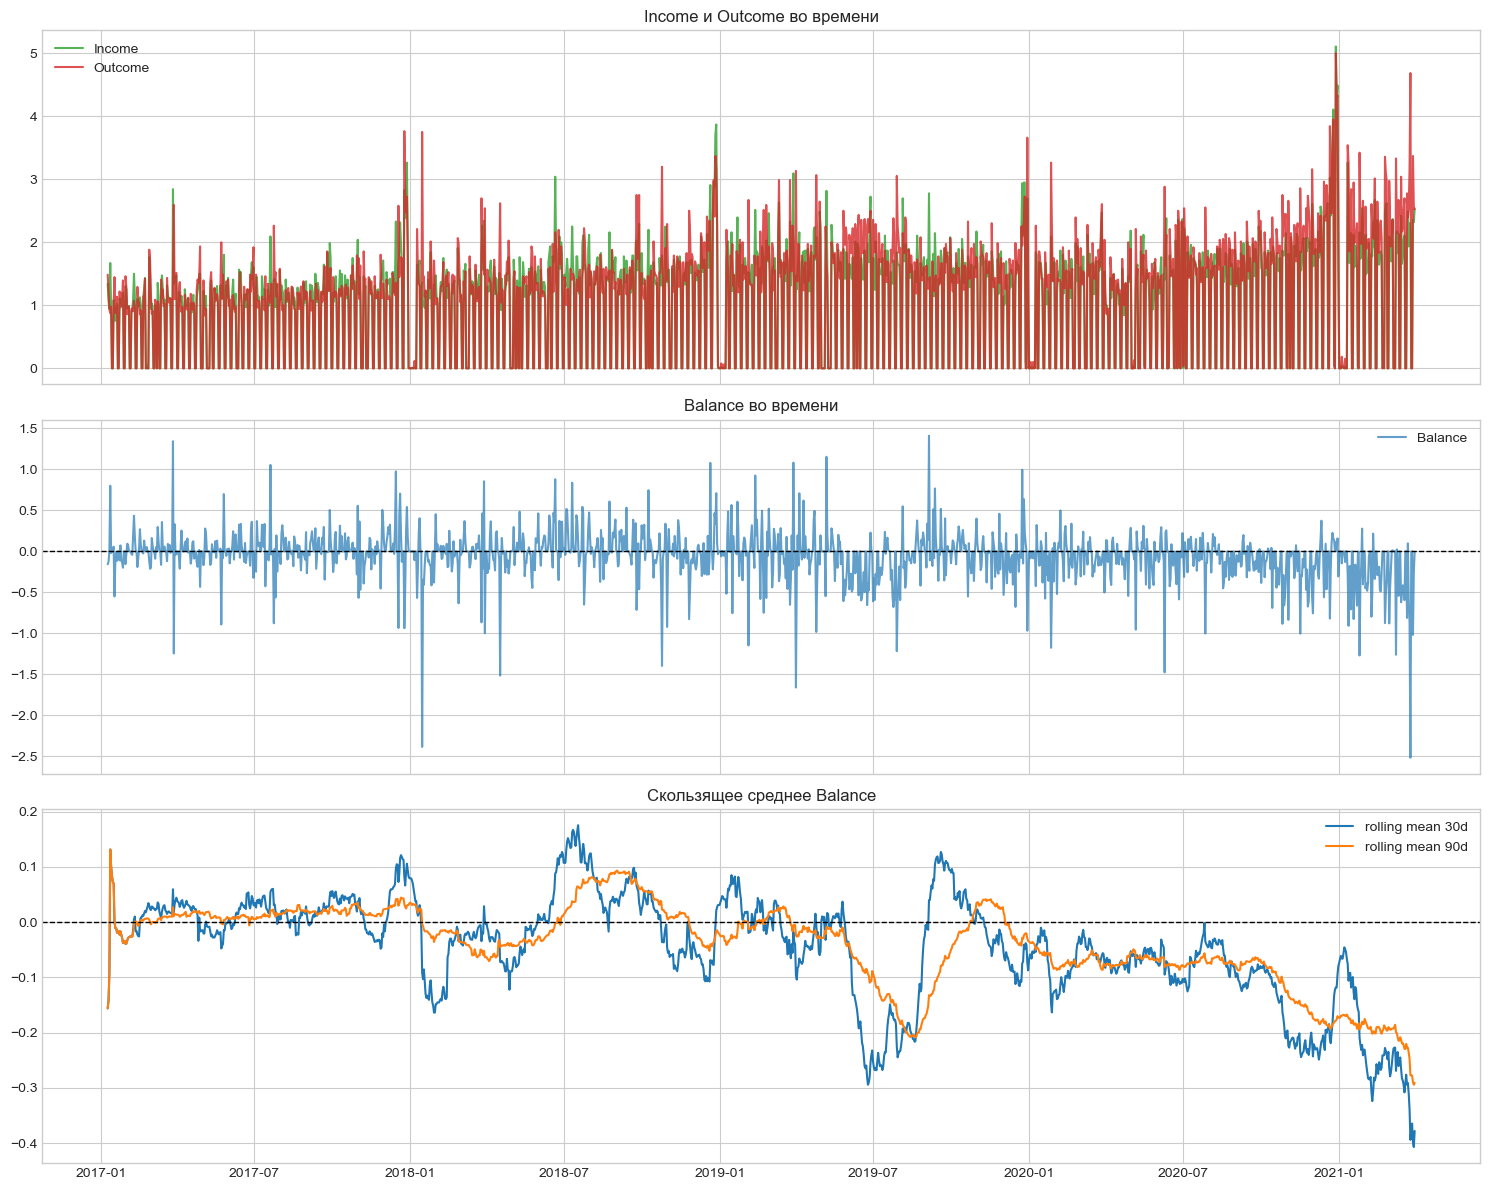

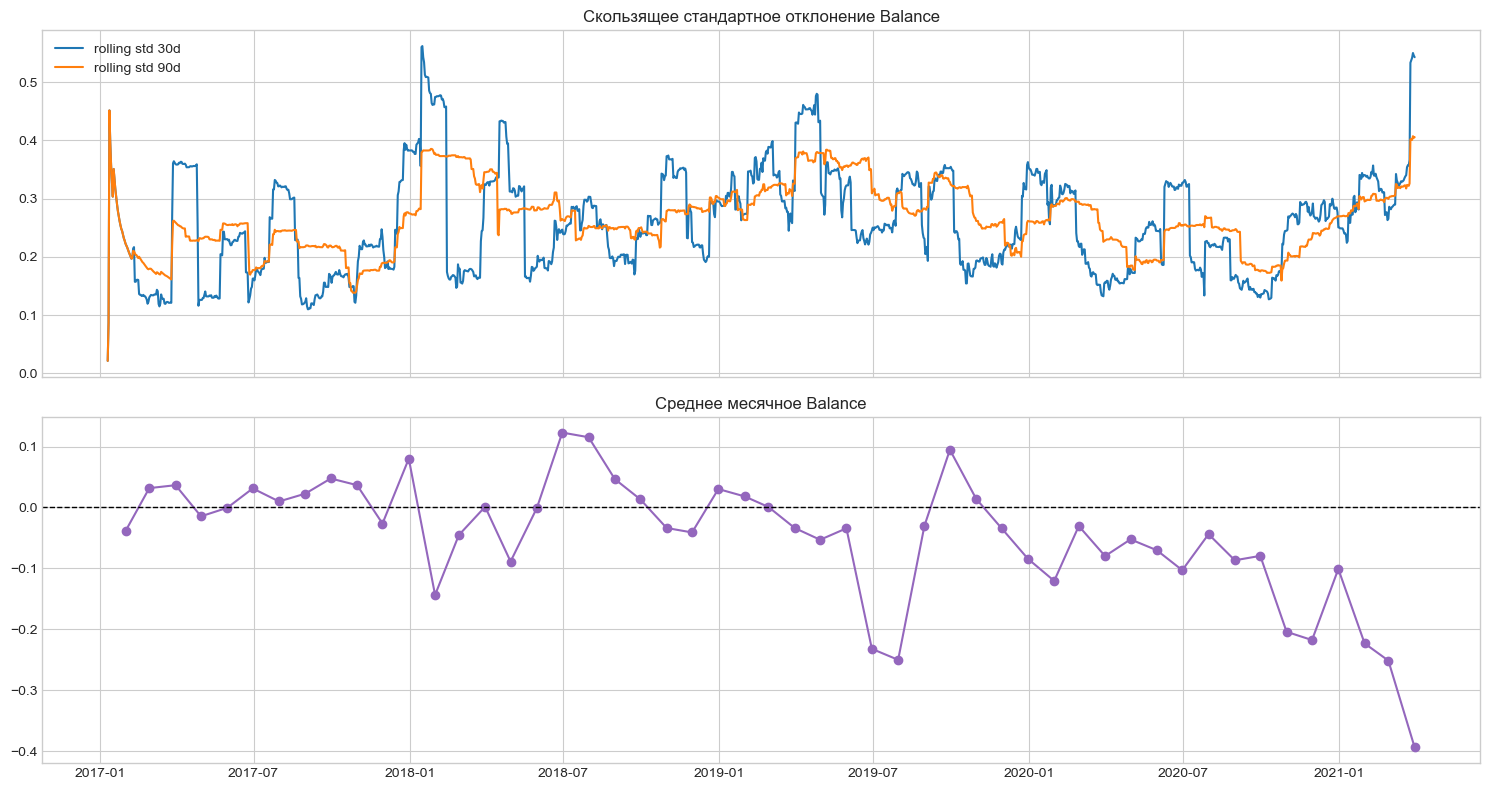

Income                            Outcome                           \
          mean       std  min       max      mean       std  min       max   
year                                                                         
2017  0.891805  0.660540  0.0  3.265402  0.872511  0.655636  0.0  3.765746   
2018  1.060957  0.804650  0.0  3.871082  1.062642  0.815472  0.0  3.752579   
2019  1.164657  0.855865  0.0  3.094232  1.217326  0.900596  0.0  3.660411   
2020  1.167842  0.918764  0.0  5.108775  1.266873  0.993531  0.0  5.003439   
2021  1.287348  1.042650  0.0  3.265402  1.577843  1.301277  0.0  4.687433   

       Balance                                
          mean       std       min       max  
year                                          
2017  0.019252  0.233250 -1.244018  1.343028  
2018 -0.001686  0.293566 -2.383217  1.079276  
2019 -0.052381  0.318789 -1.659035  1.408863  
2020 -0.099343  0.236680 -1.474698  0.498466  
2021 -0.290783  0.405545 -2.514887  0.277592

In [7]:
print("7. Временная динамика")


df_time = df.set_index("Date")
rolling_windows = [30, 90]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

axes[0].plot(df["Date"], df["Income"], label="Income", color="tab:green", alpha=0.8)
axes[0].plot(df["Date"], df["Outcome"], label="Outcome", color="tab:red", alpha=0.8)
axes[0].set_title("Income и Outcome во времени")
axes[0].legend()

axes[1].plot(df["Date"], df["Balance"], label="Balance", color="tab:blue", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Balance во времени")
axes[1].legend()

for window in rolling_windows:
    axes[2].plot(
        df["Date"],
        df["Balance"].rolling(window=window, min_periods=1).mean(),
        label=f"rolling mean {window}d",
    )
axes[2].axhline(0, color="black", linewidth=1, linestyle="--")
axes[2].set_title("Скользящее среднее Balance")
axes[2].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for window in rolling_windows:
    axes[0].plot(
        df["Date"],
        df["Balance"].rolling(window=window, min_periods=1).std(),
        label=f"rolling std {window}d",
    )
axes[0].set_title("Скользящее стандартное отклонение Balance")
axes[0].legend()

monthly_balance = df_time["Balance"].resample("ME").mean()
axes[1].plot(monthly_balance.index, monthly_balance.values, marker="o", color="tab:purple")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Среднее месячное Balance")

plt.tight_layout()
plt.show()

yearly_summary = df.assign(year=df["Date"].dt.year).groupby("year")[numeric_cols].agg(["mean", "std", "min", "max"])
display(yearly_summary)


8. Календарные эффекты


Income                               Outcome                      \
           count      mean    median       std   count      mean    median   
day_name                                                                     
Monday       221  1.545780  1.566867  0.658139     221  1.773976  1.790705   
Tuesday      221  1.506213  1.474698  0.536923     221  1.568388  1.501032   
Wednesday    221  1.380384  1.408863  0.532138     221  1.427086  1.408863   
Thursday     220  1.602584  1.586617  0.533825     220  1.567079  1.487865   
Friday       220  1.521044  1.593200  0.605387     220  1.559460  1.560283   
Saturday     220  0.032849  0.000000  0.236220     220  0.033333  0.000000   
Sunday       220  0.000156  0.000000  0.001011     220  0.000617  0.000000   

                    Balance                                
                std   count      mean    median       std  
day_name                                                   
Monday     0.810895     221 -0.228364 -0.159165  0.383496  
Tuesday    0.587190     221 -0.061966 -0.027909  0.347875  
Wednesday  0.570362     221 -0.046709 -0.004878  0.264638  
Thursday   0.579405     220  0.035356  0.035888  0.315188  
Friday     0.656279     220 -0.038588 -0.000880  0.340375  
Saturday   0.243321     220 -0.000426  0.000000  0.029707  
Sunday     0.005185     220 -0.000460  0.000000  0.004438

Income                               Outcome                      \
       count      mean    median       std   count      mean    median   
month                                                                    
1        147  0.869860  1.024187  0.833709     147  0.974869  1.138087   
2        141  1.059339  1.287537  0.812076     141  1.118026  1.307136   
3        155  1.124940  1.343028  0.865210     155  1.218597  1.329861   
4        120  0.992902  1.178905  0.707167     120  1.045044  1.240907   
5        124  0.899278  1.171515  0.769139     124  0.926361  1.249037   
6        120  1.080919  1.389113  0.832059     120  1.126676  1.234668   
7        124  1.112076  1.448364  0.754297     124  1.154389  1.408863   
8        124  1.093314  1.356195  0.734280     124  1.104978  1.336445   
9        120  1.114012  1.362779  0.786866     120  1.094259  1.336445   
10       124  1.127694  1.428614  0.742575     124  1.174605  1.402280   
11       120  1.093118  1.402280  0.798414     120  1.172877  1.395696   
12       124  1.482951  1.540533  1.191501     124  1.501468  1.606367   

                Balance                             
            std   count      mean median       std  
month                                               
1      0.967568     147 -0.105031    0.0  0.338384  
2      0.901389     141 -0.058739    0.0  0.269262  
3      1.007538     155 -0.093949    0.0  0.386096  
4      0.769143     120 -0.052178    0.0  0.286395  
5      0.795475     124 -0.026498    0.0  0.244919  
6      0.889019     120 -0.045230    0.0  0.283332  
7      0.816742     124 -0.042222    0.0  0.315872  
8      0.753072     124 -0.011899    0.0  0.186617  
9      0.784542     120  0.019017    0.0  0.242058  
10     0.812621     124 -0.046766    0.0  0.269665  
11     0.895212     120 -0.079836    0.0  0.244314  
12     1.192727     124 -0.018748    0.0  0.332294

count  \
is_weekend is_business_month_start is_business_month_end is_business_quarter_end          
False      False                   False                 False                     1002   
True       False                   False                 False                      440   
False      True                    False                 False                       50   
           False                   True                  False                       34   
                                                         True                        17   

                                                                                      mean  \
is_weekend is_business_month_start is_business_month_end is_business_quarter_end             
False      False                   False                 False                   -0.065038   
True       False                   False                 False                   -0.000443   
False      True                    False                 False                   -0.185791   
           False                   True                  False                   -0.000921   
                                                         True                    -0.041607   

                                                                                    median  \
is_weekend is_business_month_start is_business_month_end is_business_quarter_end             
False      False                   False                 False                   -0.032539   
True       False                   False                 False                    0.000000   
False      True                    False                 False                   -0.145601   
           False                   True                  False                    0.013781   
                                                         True                    -0.004878   

                                                                                       std  \
is_weekend is_business_month_start is_business_month_end is_business_quarter_end             
False      False                   False                 False                    0.340362   
True       False                   False                 False                    0.021215   
False      True                    False                 False                    0.352209   
           False                   True                  False                    0.342104   
                                                         True                     0.438500   

                                                                                       min  \
is_weekend is_business_month_start is_business_month_end is_business_quarter_end             
False      False                   False                 False                   -2.514887   
True       False                   False                 False                   -0.266053   
False      True                    False                 False                   -1.659035   
           False                   True                  False                   -0.920708   
                                                         True                    -0.996270   

                                                                                       max  
is_weekend is_business_month_start is_business_month_end is_business_quarter_end            
False      False                   False                 False                    1.408863  
True       False                   False                 False                    0.185638  
False      True                    False                 False                    0.463533  
           False                   True                  False                    0.556453  
                                                         True                     1.081942

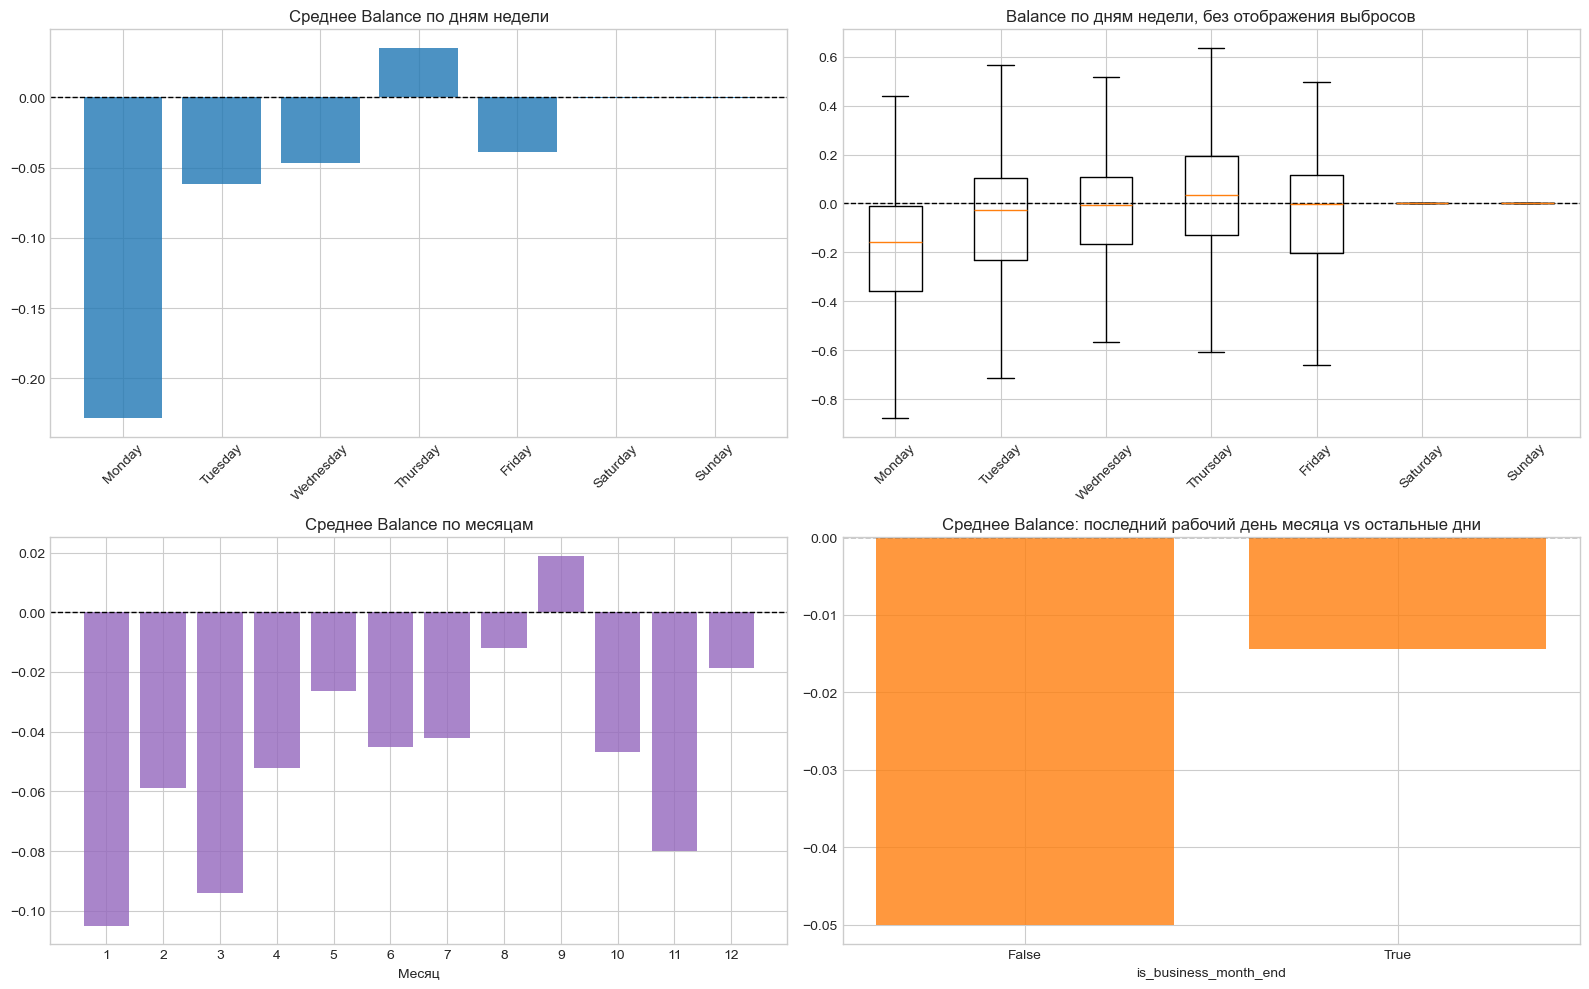

In [8]:
print("8. Календарные эффекты")


df_calendar = df.copy()
df_calendar["day_of_week"] = df_calendar["Date"].dt.dayofweek
df_calendar["day_name"] = df_calendar["Date"].dt.day_name()
df_calendar["month"] = df_calendar["Date"].dt.month
df_calendar["year"] = df_calendar["Date"].dt.year
df_calendar["is_weekend"] = df_calendar["day_of_week"].isin([5, 6])
df_calendar["is_business_month_start"] = df_calendar["Date"] == df_calendar["Date"] - pd.offsets.BMonthBegin(0)
df_calendar["is_business_month_end"] = df_calendar["Date"] == df_calendar["Date"] + pd.offsets.BMonthEnd(0)
df_calendar["is_business_quarter_end"] = df_calendar["Date"] == df_calendar["Date"] + pd.offsets.BQuarterEnd(0)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = (
    df_calendar.groupby("day_name")[numeric_cols]
    .agg(["count", "mean", "median", "std"])
    .reindex(dow_order)
)
display(dow_summary)

month_summary = df_calendar.groupby("month")[numeric_cols].agg(["count", "mean", "median", "std"])
display(month_summary)

calendar_flag_summary = df_calendar.groupby(["is_weekend", "is_business_month_start", "is_business_month_end", "is_business_quarter_end"])["Balance"].agg(["count", "mean", "median", "std", "min", "max"])
display(calendar_flag_summary.sort_values("count", ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

balance_by_dow = df_calendar.groupby("day_name")["Balance"].mean().reindex(dow_order)
axes[0, 0].bar(balance_by_dow.index, balance_by_dow.values, color="tab:blue", alpha=0.8)
axes[0, 0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0, 0].set_title("Среднее Balance по дням недели")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].boxplot(
    [df_calendar.loc[df_calendar["day_name"] == day, "Balance"].dropna() for day in dow_order],
    tick_labels=dow_order,
    showfliers=False,
)
axes[0, 1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0, 1].set_title("Balance по дням недели, без отображения выбросов")
axes[0, 1].tick_params(axis="x", rotation=45)

balance_by_month = df_calendar.groupby("month")["Balance"].mean()
axes[1, 0].bar(balance_by_month.index.astype(str), balance_by_month.values, color="tab:purple", alpha=0.8)
axes[1, 0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1, 0].set_title("Среднее Balance по месяцам")
axes[1, 0].set_xlabel("Месяц")

flag_means = df_calendar.groupby("is_business_month_end")["Balance"].mean()
axes[1, 1].bar(flag_means.index.astype(str), flag_means.values, color="tab:orange", alpha=0.8)
axes[1, 1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1, 1].set_title("Среднее Balance: последний рабочий день месяца vs остальные дни")
axes[1, 1].set_xlabel("is_business_month_end")

plt.tight_layout()
plt.show()


Заметим, что - единственный день где средний баланс не отрицательный - четверг. Более того единственный месяц где баланс не отрицательный - сентябрь, нужно понять с чем бы этого могло быть связано? Возможно приход выходных или налоговых выплат.

Также очень видно видно, что в выходные все значения нулевые, в следствии чего сами статистики сильно смещаются в сторону 0. Возможно нам стоит отказать от прогноза на каждый день, в сторону прогноза на операционные дни.

Так как в выходные значения почти нулевые и не отражают полноценную операционную активность, основная постановка задачи строится для рабочих дней. При этом календарные признаки и лаги могут учитывать структуру календаря.

Наблюдается положительное среднее значение Balance по четвергам и в сентябре. Возможные причины связаны с недельными и квартальными платёжными циклами, переносами операций с выходных/праздников и сезонностью деловой активности. Однако эффект необходимо проверить на устойчивость по годам и на чувствительность к выбросам.

In [9]:
df_calendar.groupby(["year", "day_name"])["Balance"].mean().unstack()


day_name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
year,,,,,,,
2017,0.019991,-0.070018,0.000058,0.000000,0.173998,-0.014044,0.024780
2018,0.058848,-0.112768,-0.000209,-0.000654,0.070778,-0.003227,-0.022437
2019,-0.061502,-0.309821,0.001974,-0.000996,0.034409,0.021815,-0.053974
2020,-0.049869,-0.335015,0.002019,-0.000298,-0.058697,-0.168509,-0.086068
2021,-0.521370,-0.568413,-0.022570,0.000000,-0.287858,-0.400312,-0.234731


In [10]:
df_calendar.groupby(["year", "month"])["Balance"].mean().unstack()


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2017,-0.038767,0.031746,0.036561,-0.014550,-0.000555,0.031261,0.009844,0.022671,0.047548,0.036623,-0.026435,0.080050
2018,-0.143648,-0.045347,0.001139,-0.088750,-0.000962,0.122929,0.115295,0.046456,0.013318,-0.033700,-0.041011,0.030244
2019,0.018129,0.000859,-0.033708,-0.053051,-0.034243,-0.232088,-0.250164,-0.029985,0.094665,0.014165,-0.034236,-0.084254
2020,-0.120581,-0.030517,-0.079822,-0.052363,-0.070234,-0.103022,-0.043864,-0.086739,-0.079461,-0.204152,-0.217663,-0.101034
2021,-0.223186,-0.251443,-0.393913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Особых зависимостей нет, что каждый год один и тот же день или месяц положительные - скорее всего шум

In [11]:
df_calendar

,Date,Income,Outcome,Balance,day_of_week,day_name,month,year,is_weekend,is_business_month_start,is_business_month_end,is_business_quarter_end
0,2017-01-09,1.343028,1.487865,-0.155904,0,Monday,1,2017,False,False,False,False
1,2017-01-10,1.068610,1.194182,-0.125572,1,Tuesday,1,2017,False,False,False,False
2,2017-01-11,0.944429,0.936663,0.007767,2,Wednesday,1,2017,False,False,False,False
3,2017-01-12,1.672202,0.875379,0.800391,3,Thursday,1,2017,False,False,False,False
4,2017-01-13,0.955924,0.975645,-0.019721,4,Friday,1,2017,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1538,2021-03-27,0.000000,0.000000,0.000000,5,Saturday,3,2021,True,False,False,False
1539,2021-03-28,0.000000,0.000000,0.000000,6,Sunday,3,2021,True,False,False,False
1540,2021-03-29,2.356883,3.370738,-1.017679,0,Monday,3,2021,False,False,False,False
1541,2021-03-30,2.317382,2.567554,-0.259687,1,Tuesday,3,2021,False,False,False,False


В этом блоке были сформированы следующие временные признаки:

- `day_of_week` — номер дня недели, где понедельник равен 0, воскресенье равно 6.
- `day_name` — название дня недели, используется для интерпретации и группировок.
- `month` — номер календарного месяца.
- `year` — календарный год, нужен для проверки устойчивости эффектов во времени.
- `is_weekend` — признак выходного дня: `True` для субботы и воскресенья.
- `is_business_month_start` — первый рабочий день месяца по стандартному календарю Mon-Fri.
- `is_business_month_end` — последний рабочий день месяца по стандартному календарю Mon-Fri.
- `is_business_quarter_end` — последний рабочий день квартала по стандартному календарю Mon-Fri.

Важно: рабочие признаки считаются без учета российских праздников. То есть они учитывают только перенос с субботы/воскресенья на ближайший рабочий день, но не официальный производственный календарь.

9. Сравнение всех дней и рабочих дней


,count,mean,median,std,min,max
day_type,,,,,,
business_day,1103,-0.068175,-0.032563,0.343261,-2.514887,1.408863
weekend,440,-0.000443,0.000000,0.021215,-0.266053,0.185638


,sample,count,mean,median,std,zero_share,zero_forecast_mae,zero_forecast_rmse,share_abs_le_0_42
0,all_days,1543,-0.048860,0.000000,0.292011,0.279326,0.170776,0.295977,0.887233
1,business_days_only,1103,-0.068175,-0.032563,0.343261,0.033545,0.237673,0.349813,0.842248


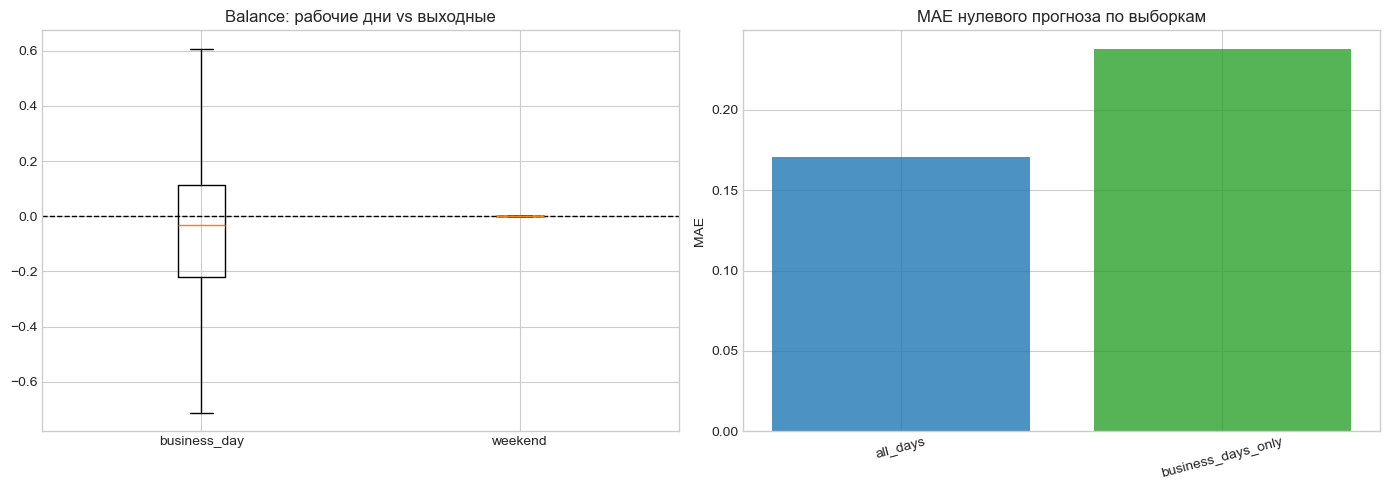

In [12]:
print("9. Сравнение всех дней и рабочих дней")

df_calendar["day_type"] = np.where(df_calendar["is_weekend"], "weekend", "business_day")

day_type_summary = (
    df_calendar.groupby("day_type")["Balance"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(["business_day", "weekend"])
)
display(day_type_summary)

comparison_rows = []
for sample_name, sample in {
    "all_days": df_calendar,
    "business_days_only": df_calendar.loc[~df_calendar["is_weekend"]],
}.items():
    y = sample["Balance"]
    comparison_rows.append({
        "sample": sample_name,
        "count": len(y),
        "mean": y.mean(),
        "median": y.median(),
        "std": y.std(),
        "zero_share": (y == 0).mean(),
        "zero_forecast_mae": y.abs().mean(),
        "zero_forecast_rmse": np.sqrt((y ** 2).mean()),
        "share_abs_le_0_42": (y.abs() <= 0.42).mean(),
    })

all_vs_business_summary = pd.DataFrame(comparison_rows)
display(all_vs_business_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    [
        df_calendar.loc[~df_calendar["is_weekend"], "Balance"],
        df_calendar.loc[df_calendar["is_weekend"], "Balance"],
    ],
    tick_labels=["business_day", "weekend"],
    showfliers=False,
)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Balance: рабочие дни vs выходные")

axes[1].bar(
    all_vs_business_summary["sample"],
    all_vs_business_summary["zero_forecast_mae"],
    color=["tab:blue", "tab:green"],
    alpha=0.8,
)
axes[1].set_title("MAE нулевого прогноза по выборкам")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


Выходные дни сильно отличаются от рабочих: значения `Balance` на них почти всегда около нуля. Это видно и по доле нулевых значений: на всех днях она составляет около 28%, а на рабочих днях — только около 3%.

Из-за этого оценка качества на всех календарных днях может быть слишком оптимистичной. Например, нулевой прогноз дает `MAE = 0.171` на всех днях и `MAE = 0.238` только на рабочих днях. Значит, выходные действительно упрощают задачу на бумаге. Для основной бизнес-постановки разумнее считать качество на рабочих днях, а календарную структуру использовать как признаки.

10. Автокорреляция Balance


ACF: обычная автокорреляция Balance с прошлыми значениями


,lag,all_days,business_days_only
0,1,0.145278,0.175675
1,2,0.083143,0.114275
2,3,0.038530,0.079976
3,5,0.068167,0.272466
4,7,0.279879,0.068130
5,14,0.174879,0.093087
6,30,0.063987,0.072155


PACF: частичная автокорреляция Balance с прошлыми значениями


,lag,all_days,business_days_only
0,1,0.145271,0.175667
1,2,0.063356,0.086049
2,3,0.018328,0.048048
3,5,0.049604,0.224368
4,7,0.245049,-0.014241
5,14,0.082702,0.026258
6,30,0.006837,-0.017634


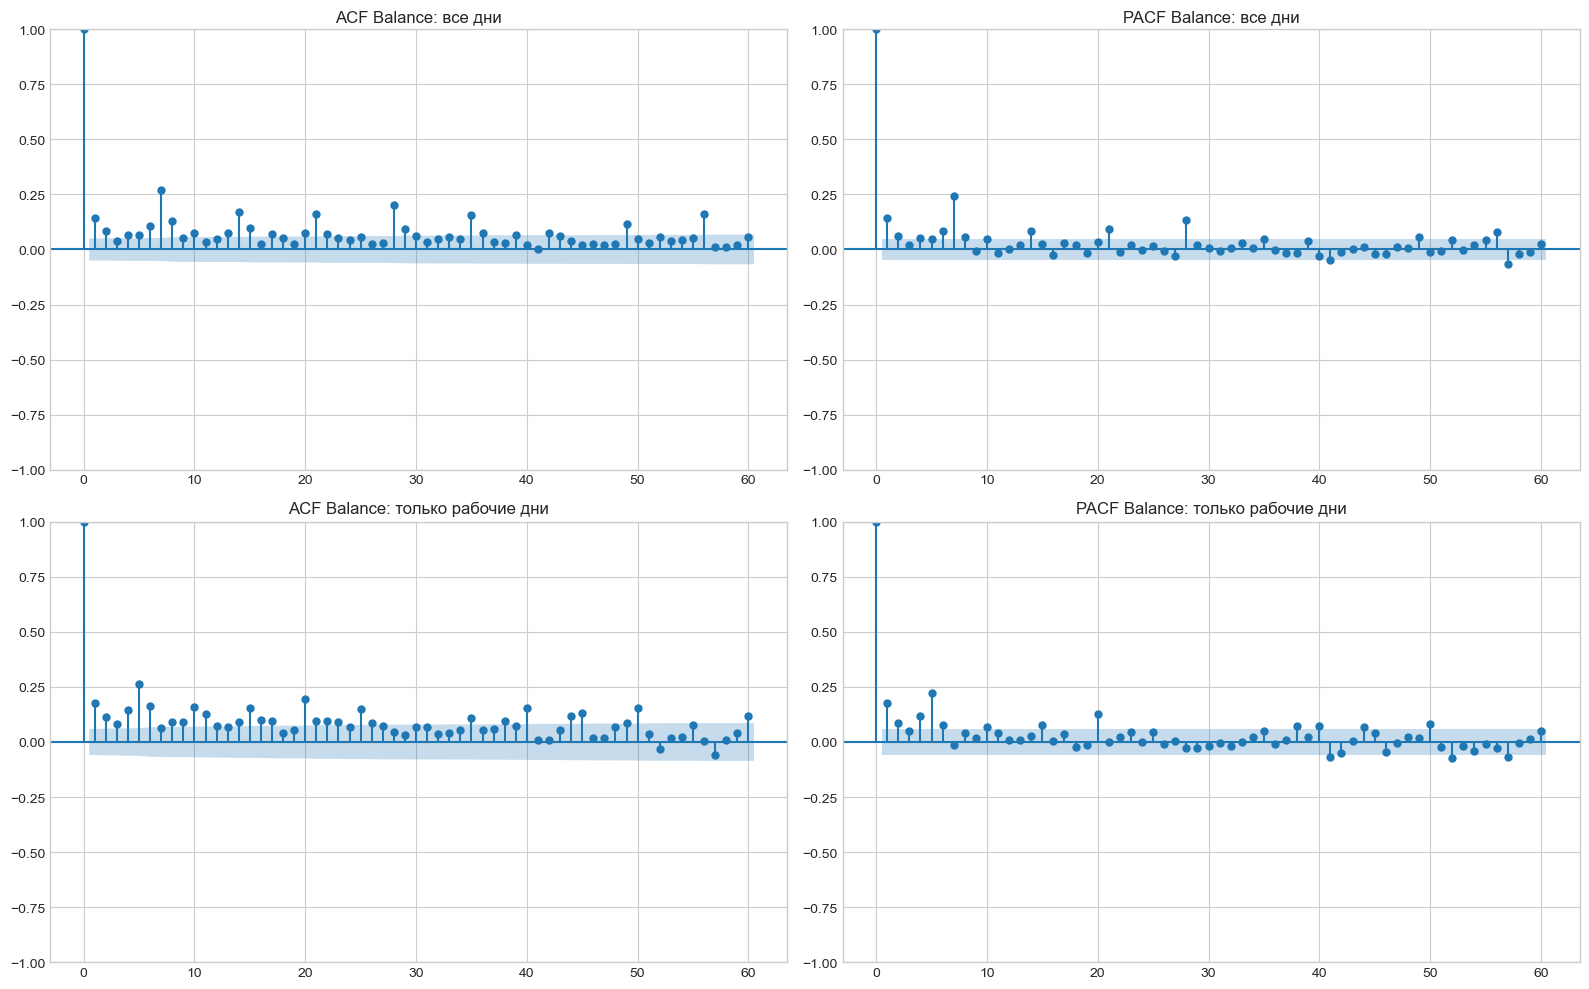

In [13]:
print("10. Автокорреляция Balance")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import pacf

balance_all_days = df_calendar["Balance"].reset_index(drop=True)
balance_business_days = df_calendar.loc[~df_calendar["is_weekend"], "Balance"].reset_index(drop=True)

selected_lags = [1, 2, 3, 5, 7, 14, 30]
autocorr_report = pd.DataFrame({
    "lag": selected_lags,
    "all_days": [balance_all_days.autocorr(lag=lag) for lag in selected_lags],
    "business_days_only": [balance_business_days.autocorr(lag=lag) for lag in selected_lags],
})
print("ACF: обычная автокорреляция Balance с прошлыми значениями")
display(autocorr_report)

pacf_all_days = pacf(balance_all_days, nlags=max(selected_lags), method="ywm")
pacf_business_days = pacf(balance_business_days, nlags=max(selected_lags), method="ywm")

partial_autocorr_report = pd.DataFrame({
    "lag": selected_lags,
    "all_days": [pacf_all_days[lag] for lag in selected_lags],
    "business_days_only": [pacf_business_days[lag] for lag in selected_lags],
})

print("PACF: частичная автокорреляция Balance с прошлыми значениями")
display(partial_autocorr_report)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(balance_all_days, lags=60, ax=axes[0, 0])
axes[0, 0].set_title("ACF Balance: все дни")

plot_pacf(balance_all_days, lags=60, method="ywm", ax=axes[0, 1])
axes[0, 1].set_title("PACF Balance: все дни")

plot_acf(balance_business_days, lags=60, ax=axes[1, 0])
axes[1, 0].set_title("ACF Balance: только рабочие дни")

plot_pacf(balance_business_days, lags=60, method="ywm", ax=axes[1, 1])
axes[1, 1].set_title("PACF Balance: только рабочие дни")

plt.tight_layout()
plt.show()


Автокорреляция нужна, чтобы понять, насколько текущий `Balance` связан с прошлыми значениями. На всех календарных днях заметна связь на лаге 7, что похоже на недельную сезонность. На рабочих днях сильнее выделяется лаг 5: это примерно предыдущая рабочая неделя.

Это означает, что лаговые признаки и авторегрессионные модели стоит проверять. Отдельный расчет для рабочих дней важен, потому что после удаления выходных лаг 1 означает предыдущий рабочий день, а не предыдущий календарный день.

Также видно, что есть небольшая связь на лаге 1, почему это может быть:
- инерция ликвидности: часть потоков тянется из одного дня в следующий;
- незавершённые расчёты или переносы платежей;
- недельный операционный цикл;
- общие рыночные/банковские условия, которые держатся несколько дней подряд.

Это важно учитывать, но это не высокая связь, скорее слабая или умеренная положительная связь

11. Скользящие средние Balance


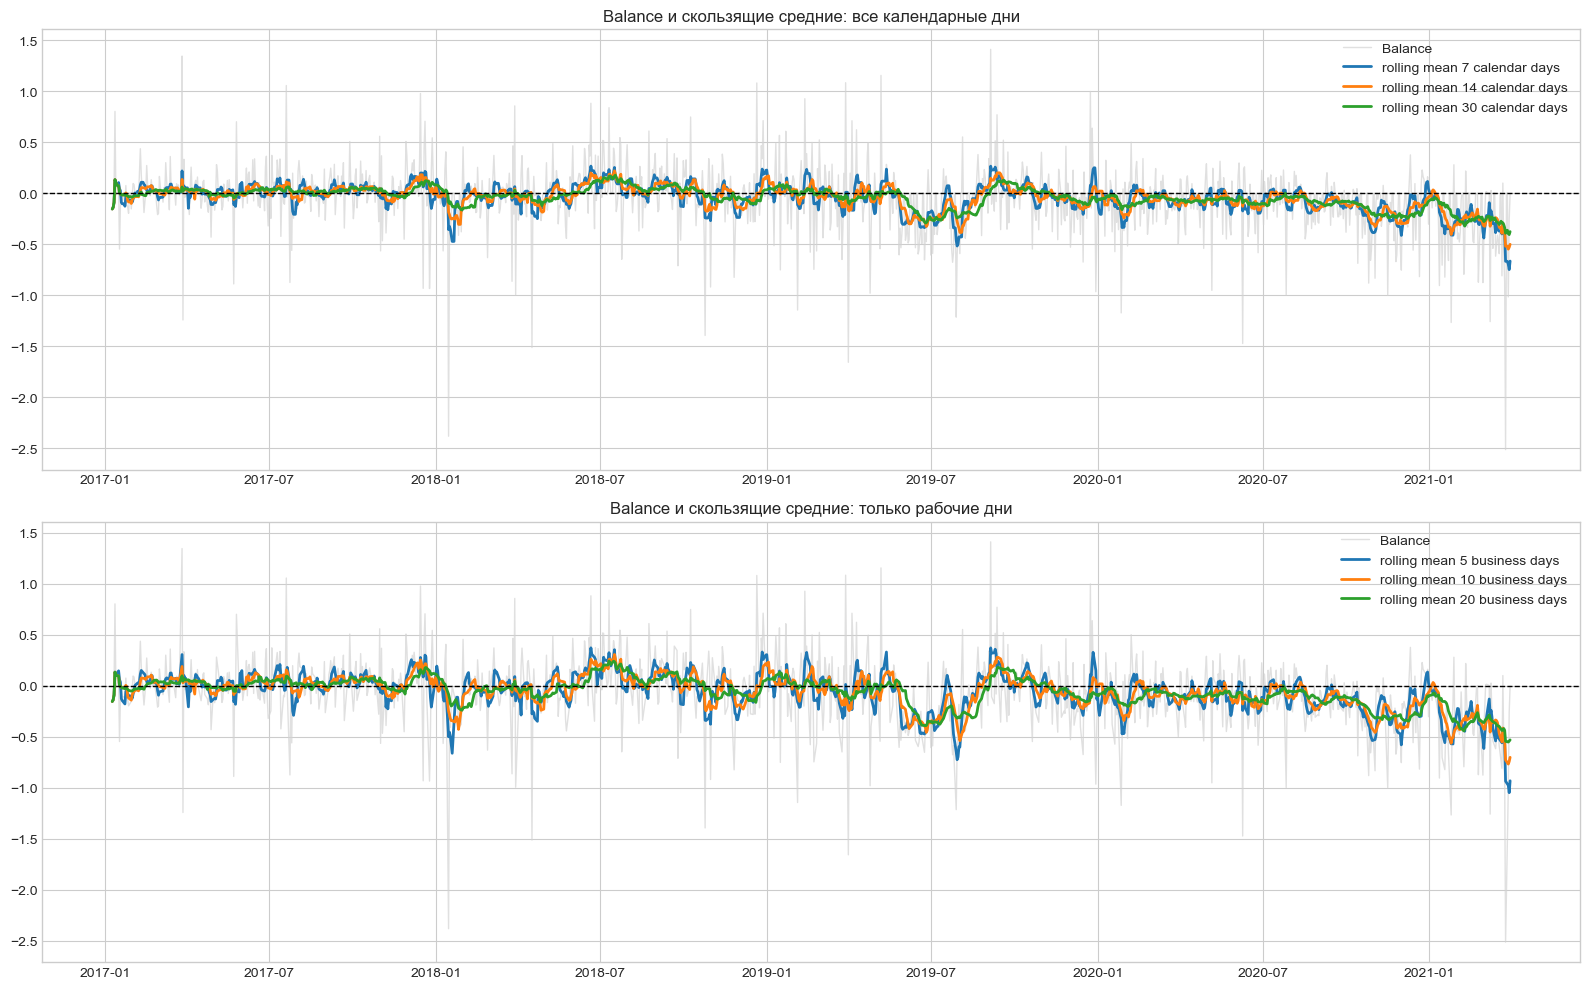

In [14]:
print("11. Скользящие средние Balance")

calendar_rolling_windows = [7, 14, 30]
business_rolling_windows = [5, 10, 20]

df_calendar_plot = df_calendar.set_index("Date")
df_business_plot = df_calendar.loc[~df_calendar["is_weekend"]].set_index("Date")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

axes[0].plot(
    df_calendar_plot.index,
    df_calendar_plot["Balance"],
    color="lightgray",
    linewidth=1,
    alpha=0.7,
    label="Balance",
)
for window in calendar_rolling_windows:
    axes[0].plot(
        df_calendar_plot.index,
        df_calendar_plot["Balance"].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f"rolling mean {window} calendar days",
    )
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Balance и скользящие средние: все календарные дни")
axes[0].legend()

axes[1].plot(
    df_business_plot.index,
    df_business_plot["Balance"],
    color="lightgray",
    linewidth=1,
    alpha=0.7,
    label="Balance",
)
for window in business_rolling_windows:
    axes[1].plot(
        df_business_plot.index,
        df_business_plot["Balance"].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f"rolling mean {window} business days",
    )
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Balance и скользящие средние: только рабочие дни")
axes[1].legend()

plt.tight_layout()
plt.show()


Скользящие средние помогают увидеть локальный режим ряда: отдельный `Balance` может быть шумным, а среднее за несколько прошлых наблюдений показывает, был ли недавний период в среднем положительным или отрицательным. Для календарного ряда естественны окна 7, 14 и 30 дней, а для рабочего ряда — 5, 10 и 20 рабочих дней. При генерации признаков такие rolling-статистики нужно считать через `shift(1)`, чтобы не использовать фактическое значение прогнозируемого дня.

Итог по автокорреляции и rolling-признакам:

- Необходимо проверить авторегрессионные модели, так как `Balance` имеет связь с прошлыми значениями.
- На лаге 1 есть слабая/умеренная положительная связь. Это означает краткосрочную инерцию ряда, поэтому `balance_lag_1` нужно включить в набор признаков.
- Для календарного ряда заметен лаг 7, что похоже на недельную сезонность. Для датасета со всеми днями нужно добавить лаги `balance_lag_1`, `balance_lag_2`, `balance_lag_3`, `balance_lag_7`, `balance_lag_14`, `balance_lag_30`.
- Для ряда рабочих дней заметен лаг 5, то есть связь с предыдущей рабочей неделей. Для рабочего датасета нужно добавить лаги `balance_lag_1`, `balance_lag_2`, `balance_lag_3`, `balance_lag_5`, `balance_lag_10`, `balance_lag_20`.
- Rolling-признаки добавляем в общий набор признаков, а не только для авторегрессионных моделей. Они описывают недавний режим ряда: средний уровень и волатильность за несколько прошлых наблюдений.
- Для календарного датасета используем окна `7`, `14`, `30` календарных дней. Для рабочего датасета используем окна `5`, `10`, `20` рабочих дней.
- Основная дальнейшая работа будет вестись с датасетом рабочих дней, потому что выходные почти нулевые и могут искусственно улучшать качество на общей календарной выборке. Календарный датасет оставляем как контрольный вариант для сравнения.

Значение будущих признаков:

- `balance_lag_k` — значение `Balance` k наблюдений назад. В рабочем датасете одно наблюдение означает один рабочий день, в календарном — один календарный день.
- `balance_rolling_mean_k` — средний `Balance` за последние k прошлых наблюдений. Признак показывает локальный уровень ряда.
- `balance_rolling_std_k` — стандартное отклонение `Balance` за последние k прошлых наблюдений. Признак показывает локальную волатильность ряда.
- `income_lag_k`, `outcome_lag_k` — значения `Income` и `Outcome` k наблюдений назад.
- `income_rolling_mean_k`, `outcome_rolling_mean_k` — средние притоки и оттоки за последние k прошлых наблюдений.

Все лаговые и rolling-признаки нужно считать только из прошлого через `shift(1)`, чтобы не было утечки фактического значения прогнозируемого дня.

## Фиксация итоговых датасетов

После анализа календарных эффектов, выходных дней, автокорреляции и скользящих средних фиксируем два варианта датасета:

- `calendar_dataset` — все календарные дни. Нужен как контрольный вариант и для проверки того, насколько качество улучшается за счет почти нулевых выходных.
- `business_dataset` — только рабочие дни. Это основной датасет для дальнейшей работы, потому что бизнес-решение по ликвидности выглядит операционным, а выходные сильно смещают метрики.

Каждая строка датасета соответствует прогнозируемой дате `Date`, а таргет `target_balance` равен фактическому `Balance` за эту дату. Все лаговые и rolling-признаки считаются только из прошлых наблюдений через `shift(1)`.

In [15]:
print("12. Итоговые датасеты для моделирования")

def build_modeling_dataset(data, lags, rolling_windows, include_weekend_feature):
    dataset = data.sort_values("Date").reset_index(drop=True).copy()
    dataset["target_balance"] = dataset["Balance"]

    feature_cols = [
        "day_of_week",
        "month",
        "is_business_month_start",
        "is_business_month_end",
        "is_business_quarter_end",
    ]
    if include_weekend_feature:
        feature_cols.append("is_weekend")

    source_columns = {
        "balance": "Balance",
        "income": "Income",
        "outcome": "Outcome",
    }

    for prefix, column in source_columns.items():
        for lag in lags:
            feature_name = f"{prefix}_lag_{lag}"
            dataset[feature_name] = dataset[column].shift(lag)
            feature_cols.append(feature_name)

    for window in rolling_windows:
        shifted_balance = dataset["Balance"].shift(1)
        mean_name = f"balance_rolling_mean_{window}"
        std_name = f"balance_rolling_std_{window}"
        dataset[mean_name] = shifted_balance.rolling(window=window, min_periods=2).mean()
        dataset[std_name] = shifted_balance.rolling(window=window, min_periods=2).std()
        feature_cols.extend([mean_name, std_name])

        for prefix, column in {"income": "Income", "outcome": "Outcome"}.items():
            feature_name = f"{prefix}_rolling_mean_{window}"
            dataset[feature_name] = dataset[column].shift(1).rolling(window=window, min_periods=2).mean()
            feature_cols.append(feature_name)

    modeling_cols = ["Date", "target_balance"] + feature_cols
    dataset = dataset[modeling_cols].dropna().reset_index(drop=True)

    return dataset, feature_cols


calendar_lags = [1, 2, 3, 7, 14, 30]
calendar_windows = [7, 14, 30]
business_lags = [1, 2, 3, 5, 10, 20]
business_windows = [5, 10, 20]

calendar_dataset, calendar_feature_cols = build_modeling_dataset(
    df_calendar,
    lags=calendar_lags,
    rolling_windows=calendar_windows,
    include_weekend_feature=True,
)

business_source = df_calendar.loc[~df_calendar["is_weekend"]].copy()
business_dataset, business_feature_cols = build_modeling_dataset(
    business_source,
    lags=business_lags,
    rolling_windows=business_windows,
    include_weekend_feature=False,
)

dataset_summary = pd.DataFrame([
    {
        "dataset": "calendar_dataset",
        "role": "контрольный",
        "rows": len(calendar_dataset),
        "features": len(calendar_feature_cols),
        "date_min": calendar_dataset["Date"].min(),
        "date_max": calendar_dataset["Date"].max(),
        "lags": calendar_lags,
        "rolling_windows": calendar_windows,
    },
    {
        "dataset": "business_dataset",
        "role": "основной",
        "rows": len(business_dataset),
        "features": len(business_feature_cols),
        "date_min": business_dataset["Date"].min(),
        "date_max": business_dataset["Date"].max(),
        "lags": business_lags,
        "rolling_windows": business_windows,
    },
])
display(dataset_summary)

feature_description = pd.DataFrame([
    {"feature_group": "calendar", "features": "day_of_week, month", "meaning": "календарная позиция прогнозируемого дня"},
    {"feature_group": "calendar", "features": "is_weekend", "meaning": "признак выходного дня; используется только в calendar_dataset"},
    {"feature_group": "calendar", "features": "is_business_month_start, is_business_month_end, is_business_quarter_end", "meaning": "первый/последний рабочий день месяца и последний рабочий день квартала"},
    {"feature_group": "lag", "features": "balance_lag_k", "meaning": "значение Balance k наблюдений назад"},
    {"feature_group": "lag", "features": "income_lag_k, outcome_lag_k", "meaning": "значения Income и Outcome k наблюдений назад"},
    {"feature_group": "rolling", "features": "balance_rolling_mean_k", "meaning": "средний Balance за последние k прошлых наблюдений"},
    {"feature_group": "rolling", "features": "balance_rolling_std_k", "meaning": "волатильность Balance за последние k прошлых наблюдений"},
    {"feature_group": "rolling", "features": "income_rolling_mean_k, outcome_rolling_mean_k", "meaning": "средние Income и Outcome за последние k прошлых наблюдений"},
])
display(feature_description)

print("calendar_dataset")
display(calendar_dataset.head())

print("business_dataset")
display(business_dataset.head())


12. Итоговые датасеты для моделирования


,dataset,role,rows,features,date_min,date_max,lags,rolling_windows
0,calendar_dataset,контрольный,1513,36,2017-02-08,2021-03-31,"[1, 2, 3, 7, 14, 30]","[7, 14, 30]"
1,business_dataset,основной,1083,35,2017-02-06,2021-03-31,"[1, 2, 3, 5, 10, 20]","[5, 10, 20]"


,feature_group,features,meaning
0,calendar,"day_of_week, month",календарная позиция прогнозируемого дня
1,calendar,is_weekend,признак выходного дня; используется только в c...
2,calendar,"is_business_month_start, is_business_month_end...",первый/последний рабочий день месяца и последн...
3,lag,balance_lag_k,значение Balance k наблюдений назад
4,lag,"income_lag_k, outcome_lag_k",значения Income и Outcome k наблюдений назад
5,rolling,balance_rolling_mean_k,средний Balance за последние k прошлых наблюдений
6,rolling,balance_rolling_std_k,волатильность Balance за последние k прошлых н...
7,rolling,"income_rolling_mean_k, outcome_rolling_mean_k",средние Income и Outcome за последние k прошлы...


calendar_dataset


,Date,target_balance,day_of_week,month,is_business_month_start,is_business_month_end,is_business_quarter_end,is_weekend,balance_lag_1,balance_lag_2,...,income_rolling_mean_7,outcome_rolling_mean_7,balance_rolling_mean_14,balance_rolling_std_14,income_rolling_mean_14,outcome_rolling_mean_14,balance_rolling_mean_30,balance_rolling_std_30,income_rolling_mean_30,outcome_rolling_mean_30
0,2017-02-08,0.196944,2,2,False,False,False,False,-0.041289,-0.032282,...,0.678058,0.662366,-0.037012,0.085140,0.754657,0.791949,-0.026060,0.196902,0.780269,0.806327
1,2017-02-09,0.434681,3,2,False,False,False,False,0.196944,-0.041289,...,0.699333,0.668836,-0.014819,0.102351,0.756261,0.771359,-0.014298,0.199401,0.772249,0.786914
2,2017-02-10,0.183553,4,2,False,False,False,False,0.434681,0.196944,...,0.773448,0.693522,0.025806,0.152141,0.793600,0.768456,0.004377,0.214299,0.786663,0.782832
3,2017-02-11,0.000000,5,2,False,False,False,True,0.183553,0.434681,...,0.796326,0.691148,0.053094,0.142792,0.790121,0.737632,0.010236,0.216784,0.793439,0.783748
4,2017-02-12,0.000000,6,2,False,False,False,True,0.000000,0.183553,...,0.796326,0.691148,0.053094,0.142792,0.790121,0.737632,-0.016443,0.157269,0.737699,0.754569


business_dataset


,Date,target_balance,day_of_week,month,is_business_month_start,is_business_month_end,is_business_quarter_end,balance_lag_1,balance_lag_2,balance_lag_3,...,income_rolling_mean_5,outcome_rolling_mean_5,balance_rolling_mean_10,balance_rolling_std_10,income_rolling_mean_10,outcome_rolling_mean_10,balance_rolling_mean_20,balance_rolling_std_20,income_rolling_mean_20,outcome_rolling_mean_20
0,2017-02-06,-0.032282,0,2,False,False,False,0.006791,0.083316,0.093309,...,1.097484,1.097761,-0.048057,0.107968,1.089327,1.137775,-0.035411,0.242454,1.079248,1.114655
1,2017-02-07,-0.041289,1,2,False,False,False,-0.032282,0.006791,0.083316,...,1.018976,0.994149,-0.040350,0.105836,1.069374,1.110116,-0.029230,0.240790,1.057656,1.087436
2,2017-02-08,0.196944,2,2,False,False,False,-0.041289,-0.032282,0.006791,...,0.949282,0.927313,-0.051817,0.098072,1.056520,1.108728,-0.025016,0.239751,1.049822,1.075388
3,2017-02-09,0.434681,3,2,False,False,False,0.196944,-0.041289,-0.032282,...,0.979066,0.936370,-0.020746,0.122454,1.058766,1.079903,-0.015557,0.244791,1.057722,1.073828
4,2017-02-10,0.183553,4,2,False,False,False,0.434681,0.196944,-0.041289,...,1.082827,0.970931,0.036128,0.181714,1.111039,1.075839,-0.033842,0.187615,1.049163,1.083645


Итогово дальше работаем с `business_dataset` как с основным датасетом. `calendar_dataset` сохраняем как контрольный вариант: он поможет показать, насколько качество модели меняется, если включить выходные дни. В обоих датасетах таргет называется `target_balance`, а список признаков хранится в `business_feature_cols` и `calendar_feature_cols`.

Из-за лаговых и rolling-признаков первые наблюдения в датасетах были отброшены: для них еще нет достаточной истории, чтобы посчитать признаки только из прошлого. Это ожидаемо и не является проблемой, потому что объем потери небольшой относительно всей выборки, а удаление первых строк защищает модель от утечки данных.

## Наивные бейзлайны

На этом этапе работаем только с `business_dataset`, то есть с рабочими днями. Цель блока — получить нижнюю планку качества, с которой потом будем сравнивать более сложные модели.

Проверяем следующие варианты:

- `zero` — всегда прогнозируем 0.
- `last_value` — прогноз равен `Balance` предыдущего рабочего дня.
- `seasonal_naive_5` — прогноз равен `Balance` за тот же рабочий день прошлой рабочей недели.
- `rolling_mean_5`, `rolling_mean_10`, `rolling_mean_20` — прогноз равен среднему `Balance` за последние 5/10/20 рабочих дней.
- `day_of_week_mean` — прогноз равен среднему `Balance` для этого дня недели на обучающей истории.

Авторегрессионные модели проверяем отдельно в пункте 5, чтобы не смешивать простые правила без обучения и обучаемые модели.

In [16]:
print("13. Наивные бейзлайны на рабочих днях")

from sklearn.metrics import mean_absolute_error, mean_squared_error


def evaluate_predictions(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "share_abs_error_le_0_42": (np.abs(errors) <= 0.42).mean(),
        "bias_mean_error": errors.mean(),
    }


modeling_data = business_dataset.sort_values("Date").reset_index(drop=True).copy()
test_size = int(len(modeling_data) * 0.2)
split_idx = len(modeling_data) - test_size

train_data = modeling_data.iloc[:split_idx].copy()
test_data = modeling_data.iloc[split_idx:].copy()

print(f"Train period: {train_data['Date'].min().date()} — {train_data['Date'].max().date()}, rows: {len(train_data)}")
print(f"Test period:  {test_data['Date'].min().date()} — {test_data['Date'].max().date()}, rows: {len(test_data)}")

y_train = train_data["target_balance"]
y_test = test_data["target_balance"]

baseline_results = []

baseline_results.append(evaluate_predictions(y_test, np.zeros(len(test_data)), "zero"))
baseline_results.append(evaluate_predictions(y_test, test_data["balance_lag_1"], "last_value"))
baseline_results.append(evaluate_predictions(y_test, test_data["balance_lag_5"], "seasonal_naive_5"))

for window in [5, 10, 20]:
    baseline_results.append(
        evaluate_predictions(
            y_test,
            test_data[f"balance_rolling_mean_{window}"],
            f"rolling_mean_{window}",
        )
    )

train_mean_by_dow = train_data.groupby("day_of_week")["target_balance"].mean()
global_train_mean = y_train.mean()
day_of_week_pred = test_data["day_of_week"].map(train_mean_by_dow).fillna(global_train_mean)
baseline_results.append(evaluate_predictions(y_test, day_of_week_pred, "day_of_week_mean"))

baseline_results_df = pd.DataFrame(baseline_results).sort_values("MAE").reset_index(drop=True)
display(baseline_results_df)


13. Наивные бейзлайны на рабочих днях


Train period: 2017-02-06 — 2020-06-02, rows: 867
Test period:  2020-06-03 — 2021-03-31, rows: 216


,model,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error
0,rolling_mean_20,0.226165,0.332408,0.875000,-0.025425
1,rolling_mean_5,0.230232,0.338820,0.865741,-0.008017
2,rolling_mean_10,0.230397,0.331990,0.875000,-0.014700
3,day_of_week_mean,0.270551,0.394827,0.800926,-0.210739
4,zero,0.290592,0.420000,0.787037,-0.237350
5,seasonal_naive_5,0.294290,0.390286,0.768519,-0.018906
6,last_value,0.294505,0.417061,0.791667,0.000581


В этом блоке используется простой временной holdout: последние 20% рабочих наблюдений оставлены для теста. Это лучше случайного разбиения, потому что во временных рядах нельзя перемешивать прошлое и будущее.

Наивные модели нужны как нижняя планка качества. Они не обучают сложные зависимости, а используют простые правила: ноль, последнее значение, недельный лаг, скользящее среднее или среднее по дню недели.

На текущем разбиении лучшим наивным вариантом оказался `rolling_mean_20`: `MAE = 0.226`, `RMSE = 0.332`, доля ошибок не больше `0.42` равна `0.875`. Этот результат используем как нижнюю планку для следующих обучаемых моделей.

Но так как основная наша метрика - `business_loss`, а дня нее необходимо знание о ключевой ставке, необходимо добавить этот признак. Заодно добавим некоторые макроэкономически факторы, такие как:
- Overnight ставка RUONIA
- Обменный курс RUB/USD

После этого проверим наши базовые бейзланы еще по `business_loss`.

In [17]:
print("14. Добавление макроэкономических признаков в business_dataset")

KEY_RATE_PATH = Path("Инфляция и ключевая ставка Банка России_F01_01_2017_T29_05_2026.xlsx")
RUONIA_PATH = Path("RC_F01_01_2017_T28_05_2026.xlsx")
USD_RUB_PATH = Path("RC_F01_01_2017_T30_05_2026.xlsx")


def parse_month_year(value):
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, (int, float, np.integer, np.floating)):
        month = int(value)
        year = int(round((float(value) - month) * 10000))
        return pd.Timestamp(year=year, month=month, day=1)
    value = str(value).strip()
    month, year = value.split(".")
    return pd.Timestamp(year=int(year), month=int(month), day=1)


macro_monthly = pd.read_excel(KEY_RATE_PATH).rename(columns={
    "Дата": "month_raw",
    "Ключевая ставка, % годовых": "key_rate",
    "Инфляция, % г/г": "inflation_yoy",
    "Цель по инфляции": "inflation_target",
})
macro_monthly["month_start"] = pd.to_datetime(macro_monthly["month_raw"].apply(parse_month_year))
macro_monthly = macro_monthly.sort_values("month_start").reset_index(drop=True)
macro_monthly["key_rate_change_1m"] = macro_monthly["key_rate"].diff()
macro_monthly["inflation_yoy_lag_1m"] = macro_monthly["inflation_yoy"].shift(1)
macro_monthly["inflation_gap_lag_1m"] = macro_monthly["inflation_yoy_lag_1m"] - macro_monthly["inflation_target"]
macro_monthly = macro_monthly[
    [
        "month_start",
        "key_rate",
        "key_rate_change_1m",
        "inflation_yoy_lag_1m",
        "inflation_target",
        "inflation_gap_lag_1m",
    ]
]

ruonia_daily = pd.read_excel(RUONIA_PATH, sheet_name="RC").rename(columns={"DT": "Date", "ruo": "ruonia"})
ruonia_daily = ruonia_daily[["Date", "ruonia", "vol"]].rename(columns={"vol": "ruonia_volume"})
ruonia_daily["Date"] = pd.to_datetime(ruonia_daily["Date"])
ruonia_daily = ruonia_daily.sort_values("Date").reset_index(drop=True)

usd_rub_daily = pd.read_excel(USD_RUB_PATH, sheet_name="RC").rename(columns={"data": "Date", "curs": "usd_rub"})
usd_rub_daily = usd_rub_daily[["Date", "usd_rub"]]
usd_rub_daily["Date"] = pd.to_datetime(usd_rub_daily["Date"])
usd_rub_daily = usd_rub_daily.sort_values("Date").reset_index(drop=True)

business_dataset_with_macro = business_dataset.sort_values("Date").reset_index(drop=True).copy()
business_dataset_with_macro["month_start"] = business_dataset_with_macro["Date"].dt.to_period("M").dt.to_timestamp()
business_dataset_with_macro = business_dataset_with_macro.merge(macro_monthly, on="month_start", how="left")

business_dataset_with_macro = pd.merge_asof(
    business_dataset_with_macro.sort_values("Date"),
    ruonia_daily,
    on="Date",
    direction="backward",
)
business_dataset_with_macro = pd.merge_asof(
    business_dataset_with_macro.sort_values("Date"),
    usd_rub_daily,
    on="Date",
    direction="backward",
)

business_dataset_with_macro["ruonia_lag_1"] = business_dataset_with_macro["ruonia"].shift(1)
business_dataset_with_macro["ruonia_volume_lag_1"] = business_dataset_with_macro["ruonia_volume"].shift(1)
business_dataset_with_macro["ruonia_spread_to_key_lag_1"] = business_dataset_with_macro["ruonia_lag_1"] - business_dataset_with_macro["key_rate"]
business_dataset_with_macro["ruonia_rolling_mean_5"] = business_dataset_with_macro["ruonia"].shift(1).rolling(window=5, min_periods=2).mean()
business_dataset_with_macro["ruonia_rolling_std_5"] = business_dataset_with_macro["ruonia"].shift(1).rolling(window=5, min_periods=2).std()

business_dataset_with_macro["usd_rub_lag_1"] = business_dataset_with_macro["usd_rub"].shift(1)
business_dataset_with_macro["usd_rub_return_1"] = business_dataset_with_macro["usd_rub_lag_1"].pct_change()
business_dataset_with_macro["usd_rub_rolling_mean_5"] = business_dataset_with_macro["usd_rub"].shift(1).rolling(window=5, min_periods=2).mean()
business_dataset_with_macro["usd_rub_rolling_std_5"] = business_dataset_with_macro["usd_rub"].shift(1).rolling(window=5, min_periods=2).std()

macro_feature_cols = [
    "key_rate",
    "key_rate_change_1m",
    "inflation_yoy_lag_1m",
    "inflation_target",
    "inflation_gap_lag_1m",
    "ruonia_lag_1",
    "ruonia_volume_lag_1",
    "ruonia_spread_to_key_lag_1",
    "ruonia_rolling_mean_5",
    "ruonia_rolling_std_5",
    "usd_rub_lag_1",
    "usd_rub_return_1",
    "usd_rub_rolling_mean_5",
    "usd_rub_rolling_std_5",
]

business_dataset_with_macro = (
    business_dataset_with_macro
    .drop(columns=["month_start", "ruonia", "ruonia_volume", "usd_rub"])
    .dropna(subset=macro_feature_cols)
    .reset_index(drop=True)
)
business_feature_cols_with_macro = business_feature_cols + macro_feature_cols

macro_dataset_summary = pd.DataFrame([
    {
        "dataset": "business_dataset",
        "rows": len(business_dataset),
        "features": len(business_feature_cols),
        "date_min": business_dataset["Date"].min(),
        "date_max": business_dataset["Date"].max(),
    },
    {
        "dataset": "business_dataset_with_macro",
        "rows": len(business_dataset_with_macro),
        "features": len(business_feature_cols_with_macro),
        "date_min": business_dataset_with_macro["Date"].min(),
        "date_max": business_dataset_with_macro["Date"].max(),
    },
])
display(macro_dataset_summary)

macro_feature_description = pd.DataFrame([
    {"feature": "key_rate", "meaning": "ключевая ставка Банка России, % годовых"},
    {"feature": "key_rate_change_1m", "meaning": "изменение ключевой ставки относительно предыдущего месяца"},
    {"feature": "inflation_yoy_lag_1m", "meaning": "годовая инфляция за предыдущий месяц, чтобы не использовать еще неизвестное значение текущего месяца"},
    {"feature": "inflation_target", "meaning": "цель Банка России по инфляции"},
    {"feature": "inflation_gap_lag_1m", "meaning": "отклонение инфляции предыдущего месяца от цели"},
    {"feature": "ruonia_lag_1", "meaning": "RUONIA за предыдущее доступное рабочее наблюдение"},
    {"feature": "ruonia_volume_lag_1", "meaning": "объем сделок RUONIA за предыдущее доступное наблюдение"},
    {"feature": "ruonia_spread_to_key_lag_1", "meaning": "спред RUONIA к ключевой ставке на предыдущем наблюдении"},
    {"feature": "ruonia_rolling_mean_5", "meaning": "средняя RUONIA за последние 5 прошлых рабочих наблюдений"},
    {"feature": "ruonia_rolling_std_5", "meaning": "волатильность RUONIA за последние 5 прошлых рабочих наблюдений"},
    {"feature": "usd_rub_lag_1", "meaning": "курс USD/RUB за предыдущее доступное наблюдение"},
    {"feature": "usd_rub_return_1", "meaning": "однодневное изменение курса USD/RUB, рассчитанное по прошлым значениям"},
    {"feature": "usd_rub_rolling_mean_5", "meaning": "средний курс USD/RUB за последние 5 прошлых рабочих наблюдений"},
    {"feature": "usd_rub_rolling_std_5", "meaning": "волатильность курса USD/RUB за последние 5 прошлых рабочих наблюдений"},
])
display(macro_feature_description)

print("Итоговый business_dataset_with_macro")
display(business_dataset_with_macro)


14. Добавление макроэкономических признаков в business_dataset


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,dataset,rows,features,date_min,date_max
0,business_dataset,1083,35,2017-02-06,2021-03-31
1,business_dataset_with_macro,1081,49,2017-02-08,2021-03-31


,feature,meaning
0,key_rate,"ключевая ставка Банка России, % годовых"
1,key_rate_change_1m,изменение ключевой ставки относительно предыду...
2,inflation_yoy_lag_1m,"годовая инфляция за предыдущий месяц, чтобы не..."
3,inflation_target,цель Банка России по инфляции
4,inflation_gap_lag_1m,отклонение инфляции предыдущего месяца от цели
5,ruonia_lag_1,RUONIA за предыдущее доступное рабочее наблюдение
6,ruonia_volume_lag_1,объем сделок RUONIA за предыдущее доступное на...
7,ruonia_spread_to_key_lag_1,спред RUONIA к ключевой ставке на предыдущем н...
8,ruonia_rolling_mean_5,средняя RUONIA за последние 5 прошлых рабочих ...
9,ruonia_rolling_std_5,волатильность RUONIA за последние 5 прошлых ра...


Итоговый business_dataset_with_macro


,Date,target_balance,day_of_week,month,is_business_month_start,is_business_month_end,is_business_quarter_end,balance_lag_1,balance_lag_2,balance_lag_3,...,inflation_gap_lag_1m,ruonia_lag_1,ruonia_volume_lag_1,ruonia_spread_to_key_lag_1,ruonia_rolling_mean_5,ruonia_rolling_std_5,usd_rub_lag_1,usd_rub_return_1,usd_rub_rolling_mean_5,usd_rub_rolling_std_5
0,2017-02-08,0.196944,2,2,False,False,False,-0.041289,-0.032282,0.006791,...,1.0,9.90,86.47,-0.10,9.835,0.091924,58.7121,-0.010143,59.012900,0.425395
1,2017-02-09,0.434681,3,2,False,False,False,0.196944,-0.041289,-0.032282,...,1.0,10.24,90.67,0.24,9.970,0.242693,59.1933,0.008196,59.073033,0.318322
2,2017-02-10,0.183553,4,2,False,False,False,0.434681,0.196944,-0.041289,...,1.0,10.25,95.94,0.25,10.040,0.242625,59.5129,0.005399,59.183000,0.340475
3,2017-02-13,-0.190470,0,2,False,False,False,0.183553,0.434681,0.196944,...,1.0,10.30,90.29,0.30,10.092,0.240146,59.0235,-0.008223,59.151100,0.303365
4,2017-02-14,-0.086178,1,2,False,False,False,-0.190470,0.183553,0.434681,...,1.0,10.21,57.18,0.21,10.180,0.159844,58.8457,-0.003012,59.057500,0.312709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076,2021-03-25,-0.869810,3,3,False,False,False,-0.587778,0.098041,-0.810884,...,1.7,4.28,115.72,-0.22,4.198,0.070852,75.3585,0.010052,74.173220,0.867251
1077,2021-03-26,-2.514887,4,3,False,False,False,-0.869810,-0.587778,0.098041,...,1.7,4.41,89.85,-0.09,4.258,0.099096,76.1535,0.010550,74.783540,0.989928
1078,2021-03-29,-1.017679,0,3,False,False,False,-2.514887,-0.869810,-0.587778,...,1.7,4.31,118.50,-0.19,4.292,0.074632,76.1741,0.000271,75.286720,0.911201
1079,2021-03-30,-0.259687,1,3,False,False,False,-1.017679,-2.514887,-0.869810,...,1.7,4.45,89.45,-0.05,4.334,0.094499,75.7576,-0.005468,75.610440,0.652235


В `business_dataset_with_macro` добавлены макроэкономические признаки из трех внешних файлов: ключевая ставка и инфляция, RUONIA, курс USD/RUB. Чтобы не подглядывать в значение прогнозируемого дня, дневные рыночные признаки (`RUONIA` и `USD/RUB`) добавлены с лагом 1, а инфляция используется с лагом один месяц. Ключевая ставка оставлена на текущую дату, потому что она известна на момент принятия решения и нужна для дальнейшего расчета `business_loss`.

## Пересчет бейзлайнов по бизнес-метрике

Теперь пересчитаем те же базовые модели на `business_dataset_with_macro`, потому что для `business_loss` нужна ключевая ставка.

Финансовую логику задаем так:

- если прогноз `y_pred > 0`, прогнозируемый профицит размещается в инструмент с доходностью `key_rate + 0.5%`;
- если после размещения фактического `Balance` не хватает, недостающая ликвидность покрывается займом по `key_rate + 1%`;
- если после решения остается профицит, он размещается в ЦБ overnight по `key_rate - 0.9%`;
- идеальная стратегия знает фактический `Balance`: положительный `Balance` размещает в доходный инструмент, отрицательный покрывает займом.

`business_loss = ideal_profit - model_profit`. Чем меньше `business_loss`, тем лучше модель с точки зрения бизнес-цели.

In [18]:
print("15. Бейзлайны с учетом business_loss")


def calculate_model_profit(y_true, y_pred, key_rate):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    key_rate = np.asarray(key_rate) / 100

    derivative_rate = (key_rate + 0.005) / 365
    cb_overnight_rate = (key_rate - 0.009) / 365
    borrow_rate = (key_rate + 0.010) / 365

    placed_amount = np.maximum(y_pred, 0)
    residual_balance = y_true - placed_amount

    derivative_profit = placed_amount * derivative_rate
    residual_profit = np.where(
        residual_balance >= 0,
        residual_balance * cb_overnight_rate,
        residual_balance * borrow_rate,
    )

    return derivative_profit + residual_profit


def calculate_ideal_profit(y_true, key_rate):
    y_true = np.asarray(y_true)
    key_rate = np.asarray(key_rate) / 100

    derivative_rate = (key_rate + 0.005) / 365
    borrow_rate = (key_rate + 0.010) / 365

    return np.where(
        y_true >= 0,
        y_true * derivative_rate,
        y_true * borrow_rate,
    )


def evaluate_predictions_with_business_loss(y_true, y_pred, key_rate, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred
    model_profit = calculate_model_profit(y_true, y_pred, key_rate)
    ideal_profit = calculate_ideal_profit(y_true, key_rate)
    business_loss = ideal_profit - model_profit

    return {
        "model": model_name,
        "business_loss": business_loss.sum(),
        "business_loss_mean": business_loss.mean(),
        "model_profit": model_profit.sum(),
        "ideal_profit": ideal_profit.sum(),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "share_abs_error_le_0_42": (np.abs(errors) <= 0.42).mean(),
        "bias_mean_error": errors.mean(),
    }


modeling_data_macro = business_dataset_with_macro.sort_values("Date").reset_index(drop=True).copy()
test_size_macro = int(len(modeling_data_macro) * 0.2)
split_idx_macro = len(modeling_data_macro) - test_size_macro

train_data_macro = modeling_data_macro.iloc[:split_idx_macro].copy()
test_data_macro = modeling_data_macro.iloc[split_idx_macro:].copy()

print(f"Train period: {train_data_macro['Date'].min().date()} — {train_data_macro['Date'].max().date()}, rows: {len(train_data_macro)}")
print(f"Test period:  {test_data_macro['Date'].min().date()} — {test_data_macro['Date'].max().date()}, rows: {len(test_data_macro)}")

y_train_macro = train_data_macro["target_balance"]
y_test_macro = test_data_macro["target_balance"]
key_rate_test = test_data_macro["key_rate"]

business_baseline_results = []

business_baseline_results.append(
    evaluate_predictions_with_business_loss(y_test_macro, np.zeros(len(test_data_macro)), key_rate_test, "zero")
)
business_baseline_results.append(
    evaluate_predictions_with_business_loss(y_test_macro, test_data_macro["balance_lag_1"], key_rate_test, "last_value")
)
business_baseline_results.append(
    evaluate_predictions_with_business_loss(y_test_macro, test_data_macro["balance_lag_5"], key_rate_test, "seasonal_naive_5")
)

for window in [5, 10, 20]:
    business_baseline_results.append(
        evaluate_predictions_with_business_loss(
            y_test_macro,
            test_data_macro[f"balance_rolling_mean_{window}"],
            key_rate_test,
            f"rolling_mean_{window}",
        )
    )

train_mean_by_dow_macro = train_data_macro.groupby("day_of_week")["target_balance"].mean()
global_train_mean_macro = y_train_macro.mean()
day_of_week_pred_macro = test_data_macro["day_of_week"].map(train_mean_by_dow_macro).fillna(global_train_mean_macro)
business_baseline_results.append(
    evaluate_predictions_with_business_loss(y_test_macro, day_of_week_pred_macro, key_rate_test, "day_of_week_mean")
)

business_baseline_results_df = (
    pd.DataFrame(business_baseline_results)
    .sort_values("business_loss")
    .reset_index(drop=True)
)
display(business_baseline_results_df)


15. Бейзлайны с учетом business_loss
Train period: 2017-02-08 — 2020-06-02, rows: 865
Test period:  2020-06-03 — 2021-03-31, rows: 216


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error
0,rolling_mean_5,0.000220,0.000001,-0.007776,-0.007556,0.230232,0.338820,0.865741,-0.008017
1,zero,0.000221,0.000001,-0.007777,-0.007556,0.290592,0.420000,0.787037,-0.237350
2,rolling_mean_20,0.000221,0.000001,-0.007777,-0.007556,0.226165,0.332408,0.875000,-0.025425
3,rolling_mean_10,0.000222,0.000001,-0.007778,-0.007556,0.230397,0.331990,0.875000,-0.014700
4,day_of_week_mean,0.000226,0.000001,-0.007782,-0.007556,0.270478,0.394739,0.800926,-0.210603
5,last_value,0.000227,0.000001,-0.007783,-0.007556,0.294505,0.417061,0.791667,0.000581
6,seasonal_naive_5,0.000243,0.000001,-0.007799,-0.007556,0.294290,0.390286,0.768519,-0.018906


Таблица выше отсортирована по `business_loss`, а не по `MAE`. Это важно: модель с меньшей средней абсолютной ошибкой не обязана быть лучшей с точки зрения финансового результата, потому что завышение и занижение прогноза имеют разные последствия для стратегии управления ликвидностью.

На текущем тестовом периоде лучший результат среди наивных моделей по `business_loss` дает `rolling_mean_5`. При этом первые наивные модели отличаются слабо, поэтому для дальнейшего выбора модели нужно смотреть не только на одну holdout-выборку, а использовать временную кросс-валидацию и проверить устойчивость результата.

## Исследование авторегрессионных моделей

По плану проекта отдельно проверяем возможность применения авторегрессионных моделей. Работаем с основным датасетом рабочих дней и оцениваем модели по той же holdout-выборке, что и бейзлайны.

Проверяем два варианта:

- линейная авторегрессия на лагах `Balance`: модель обучается на признаках `balance_lag_*` и делает one-step прогноз для каждой даты теста;
- `AutoReg` из `statsmodels`: классическая авторегрессионная модель, которая строит рекурсивный прогноз на тестовый период.

Сравниваем несколько наборов лагов: короткую инерцию, недельный лаг и более длинные рабочие циклы.

In [19]:
print("16. Исследование авторегрессионных моделей")

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.ar_model import AutoReg

autoreg_lag_sets = {
    "lags_1": [1],
    "lags_1_5": [1, 5],
    "lags_1_2_3_5": [1, 2, 3, 5],
    "lags_1_2_3_5_10_20": [1, 2, 3, 5, 10, 20],
}

autoreg_results = []

for lag_set_name, lags in autoreg_lag_sets.items():
    lag_features = [f"balance_lag_{lag}" for lag in lags]

    linear_model = LinearRegression()
    linear_model.fit(train_data_macro[lag_features], y_train_macro)
    linear_pred = linear_model.predict(test_data_macro[lag_features])
    linear_result = evaluate_predictions_with_business_loss(
        y_test_macro,
        linear_pred,
        key_rate_test,
        f"linear_autoreg_{lag_set_name}",
    )
    linear_result["lag_set"] = lags
    linear_result["forecast_type"] = "one_step_with_observed_lags"
    autoreg_results.append(linear_result)

    statsmodels_model = AutoReg(y_train_macro, lags=lags, old_names=False).fit()
    statsmodels_pred = statsmodels_model.forecast(steps=len(test_data_macro))
    statsmodels_result = evaluate_predictions_with_business_loss(
        y_test_macro,
        statsmodels_pred,
        key_rate_test,
        f"statsmodels_autoreg_{lag_set_name}",
    )
    statsmodels_result["lag_set"] = lags
    statsmodels_result["forecast_type"] = "recursive_forecast"
    autoreg_results.append(statsmodels_result)

autoreg_results_df = (
    pd.DataFrame(autoreg_results)
    .sort_values("business_loss")
    .reset_index(drop=True)
)
display(autoreg_results_df)


16. Исследование авторегрессионных моделей


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,lag_set,forecast_type
0,linear_autoreg_lags_1_2_3_5_10_20,0.000220,0.000001,-0.007776,-0.007556,0.233604,0.345273,0.856481,-0.119798,"[1, 2, 3, 5, 10, 20]",one_step_with_observed_lags
1,statsmodels_autoreg_lags_1_2_3_5_10_20,0.000220,0.000001,-0.007776,-0.007556,0.276605,0.402648,0.805556,-0.204383,"[1, 2, 3, 5, 10, 20]",recursive_forecast
2,statsmodels_autoreg_lags_1,0.000221,0.000001,-0.007777,-0.007556,0.277909,0.405323,0.796296,-0.210254,[1],recursive_forecast
3,statsmodels_autoreg_lags_1_5,0.000221,0.000001,-0.007777,-0.007556,0.277277,0.404516,0.796296,-0.208765,"[1, 5]",recursive_forecast
4,statsmodels_autoreg_lags_1_2_3_5,0.000221,0.000001,-0.007777,-0.007556,0.277320,0.404525,0.796296,-0.208681,"[1, 2, 3, 5]",recursive_forecast
5,linear_autoreg_lags_1,0.000221,0.000001,-0.007777,-0.007556,0.266212,0.390801,0.814815,-0.193124,[1],one_step_with_observed_lags
6,linear_autoreg_lags_1_5,0.000221,0.000001,-0.007777,-0.007556,0.247267,0.363678,0.856481,-0.155050,"[1, 5]",one_step_with_observed_lags
7,linear_autoreg_lags_1_2_3_5,0.000222,0.000001,-0.007778,-0.007556,0.243825,0.360087,0.861111,-0.147152,"[1, 2, 3, 5]",one_step_with_observed_lags


Этот блок закрывает требование отдельно исследовать авторегрессионные модели. На текущем holdout-периоде лучший авторегрессионный вариант по `business_loss` — линейная авторегрессия на лагах `[1, 2, 3, 5, 10, 20]`. Это подтверждает, что прошлые значения `Balance` полезны для прогноза.

При этом по `MAE` авторегрессия не превосходит лучший rolling-бейзлайн из предыдущего блока. Поэтому авторегрессионные модели стоит оставить как важный базовый класс, но финальный выбор нужно делать после временной кросс-валидации и сравнения с ML-моделями на расширенном наборе признаков.

## Отбор признаков

Теперь переходим к модулю отбора признаков. Работаем с `business_dataset_with_macro`, потому что это основной датасет рабочих дней с добавленными макроэкономическими факторами.

Сравниваем методы из трех категорий:

- фильтрационные методы: Spearman correlation и mutual information;
- встроенные методы: Lasso и Random Forest feature importance;
- оберточный метод: RFE с линейной регрессией.

Mutual information и Random Forest позволяют учитывать нелинейные зависимости. Для каждого метода дополнительно считаем стабильность отбора на временных фолдах через средний Jaccard similarity между выбранными наборами признаков.

In [20]:
print("17. Отбор признаков")

import warnings
from itertools import combinations

from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)


N_SELECTED_FEATURES = 15
feature_selection_cv = TimeSeriesSplit(n_splits=4)

candidate_feature_cols = business_feature_cols_with_macro.copy()
X_train_fs = train_data_macro[candidate_feature_cols].astype(float)
y_train_fs = train_data_macro["target_balance"]
X_test_fs = test_data_macro[candidate_feature_cols].astype(float)
y_test_fs = test_data_macro["target_balance"]


def average_jaccard(feature_sets):
    scores = []
    for left, right in combinations(feature_sets, 2):
        left = set(left)
        right = set(right)
        scores.append(len(left & right) / len(left | right))
    return float(np.mean(scores)) if scores else np.nan


def select_features(method_name, X, y, n_features=N_SELECTED_FEATURES):
    if method_name == "filter_spearman":
        scores = {}
        for column in X.columns:
            if X[column].nunique(dropna=False) <= 1:
                scores[column] = 0
            else:
                scores[column] = abs(X[column].corr(y, method="spearman"))
        scores = pd.Series(scores).fillna(0)
        return scores.sort_values(ascending=False).head(n_features).index.tolist()

    if method_name == "filter_mutual_info":
        scores = mutual_info_regression(X, y, random_state=42)
        scores = pd.Series(scores, index=X.columns)
        return scores.sort_values(ascending=False).head(n_features).index.tolist()

    if method_name == "embedded_lasso":
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = LassoCV(
            alphas=np.logspace(-4, 0, 60),
            cv=TimeSeriesSplit(n_splits=3),
            max_iter=20000,
            random_state=42,
        )
        model.fit(X_scaled, y)
        scores = pd.Series(np.abs(model.coef_), index=X.columns)
        selected = scores[scores > 1e-8].sort_values(ascending=False).head(n_features).index.tolist()
        if len(selected) < n_features:
            selected = scores.sort_values(ascending=False).head(n_features).index.tolist()
        return selected

    if method_name == "embedded_random_forest":
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X, y)
        scores = pd.Series(model.feature_importances_, index=X.columns)
        return scores.sort_values(ascending=False).head(n_features).index.tolist()

    if method_name == "wrapper_rfe_linear":
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        selector = RFE(
            estimator=LinearRegression(),
            n_features_to_select=n_features,
            step=0.2,
        )
        selector.fit(X_scaled, y)
        return X.columns[selector.support_].tolist()

    raise ValueError(f"Unknown method: {method_name}")


feature_selection_methods = {
    "filter_spearman": "filter",
    "filter_mutual_info": "filter_nonlinear",
    "embedded_lasso": "embedded",
    "embedded_random_forest": "embedded_nonlinear",
    "wrapper_rfe_linear": "wrapper",
}

selected_feature_sets = {}
feature_selection_rows = []

for method_name, method_category in feature_selection_methods.items():
    selected_features = select_features(method_name, X_train_fs, y_train_fs)
    selected_feature_sets[method_name] = selected_features

    fold_selected_features = []
    for train_idx, _ in feature_selection_cv.split(X_train_fs):
        fold_X = X_train_fs.iloc[train_idx]
        fold_y = y_train_fs.iloc[train_idx]
        fold_selected_features.append(select_features(method_name, fold_X, fold_y))

    stability = average_jaccard(fold_selected_features)

    evaluation_model = LinearRegression()
    evaluation_model.fit(train_data_macro[selected_features], y_train_macro)
    prediction = evaluation_model.predict(test_data_macro[selected_features])
    result = evaluate_predictions_with_business_loss(
        y_test_macro,
        prediction,
        key_rate_test,
        method_name,
    )
    result["method_category"] = method_category
    result["n_features"] = len(selected_features)
    result["stability_jaccard"] = stability
    result["selected_features"] = selected_features
    feature_selection_rows.append(result)

feature_selection_results_df = pd.DataFrame(feature_selection_rows)
feature_selection_results_df["business_loss_rank"] = feature_selection_results_df["business_loss"].rank(method="min")
feature_selection_results_df["stability_rank"] = feature_selection_results_df["stability_jaccard"].rank(ascending=False, method="min")
feature_selection_results_df["combined_rank"] = feature_selection_results_df["business_loss_rank"] + feature_selection_results_df["stability_rank"]
feature_selection_results_df = feature_selection_results_df.sort_values(
    ["combined_rank", "business_loss", "stability_jaccard"]
    , ascending=[True, True, False]
).reset_index(drop=True)

display(feature_selection_results_df.drop(columns=["selected_features"]))

best_business_loss = feature_selection_results_df["business_loss"].min()
eligible_methods = feature_selection_results_df[
    feature_selection_results_df["business_loss"] <= best_business_loss * 1.05
].copy()
chosen_feature_selection_method = eligible_methods.sort_values(
    ["stability_jaccard", "business_loss"],
    ascending=[False, True],
).iloc[0]["model"]
selected_feature_cols = selected_feature_sets[chosen_feature_selection_method]

print(f"Выбранный метод отбора признаков: {chosen_feature_selection_method}")
print(f"Количество выбранных признаков: {len(selected_feature_cols)}")

selected_features_df = pd.DataFrame({"selected_feature": selected_feature_cols})
display(selected_features_df)


17. Отбор признаков


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,method_category,n_features,stability_jaccard,business_loss_rank,stability_rank,combined_rank
0,embedded_random_forest,0.000218,1.007616e-06,-0.007774,-0.007556,0.214998,0.323338,0.870370,-0.074526,embedded_nonlinear,15,0.443894,2.0,1.0,3.0
1,filter_spearman,0.000216,9.989064e-07,-0.007772,-0.007556,0.216344,0.324505,0.875000,-0.085028,filter,15,0.373665,1.0,4.0,5.0
2,embedded_lasso,0.000218,1.008258e-06,-0.007774,-0.007556,0.215586,0.322570,0.875000,-0.074664,embedded,15,0.387364,3.0,2.0,5.0
3,filter_mutual_info,0.000220,1.018613e-06,-0.007776,-0.007556,0.216137,0.319547,0.865741,-0.058637,filter_nonlinear,15,0.381211,4.0,3.0,7.0
4,wrapper_rfe_linear,0.000223,1.033102e-06,-0.007779,-0.007556,0.228926,0.335102,0.861111,-0.100554,wrapper,15,0.350316,5.0,5.0,10.0


Выбранный метод отбора признаков: embedded_random_forest
Количество выбранных признаков: 15


,selected_feature
0,outcome_lag_20
1,day_of_week
2,balance_lag_5
3,balance_rolling_mean_10
4,balance_lag_20
5,outcome_lag_1
6,balance_lag_1
7,balance_rolling_mean_5
8,ruonia_rolling_std_5
9,usd_rub_rolling_std_5


В этом блоке модуль отбора признаков сравнивает методы разных категорий и выбирает итоговый набор признаков не только по качеству на holdout, но и с учетом стабильности выбора на временных фолдах. Итоговый список сохраняется в `selected_feature_cols`, а выбранный метод — в `chosen_feature_selection_method`.

Стабильность важна, потому что нестабильный метод может выбирать разные признаки на соседних временных периодах. Для автоматизированного пайплайна предпочтительнее метод, который дает сопоставимое качество и при этом устойчивее во времени.

По результатам сравнения выбран `embedded_random_forest`: он дал почти лучший `business_loss` и самую высокую стабильность отбора. В итоговый набор вошли лаги `Balance`, `Income` и `Outcome`, rolling-признаки `Balance`, календарный признак `day_of_week`, а также несколько макрофакторов: волатильность RUONIA, волатильность USD/RUB, изменение USD/RUB, спред RUONIA к ключевой ставке и объем RUONIA. Это выглядит экономически правдоподобно: модель использует как внутреннюю динамику ликвидности, так и состояние денежного рынка.

## Проверка устойчивости на сдвиге режима с 2020-01-01

На графиках видно, что примерно с начала 2020 года поведение `Balance` меняется. Поэтому дополнительно проверим более строгий сценарий: обучаемся только на данных до `2020-01-01`, а тестируемся на периоде с `2020-01-01` и дальше.

Это не заменяет обычный holdout, а дополняет его: такой split показывает, насколько модели устойчивы к возможному структурному сдвигу.

In [21]:
print("18. Проверка устойчивости на regime-shift split")

REGIME_SPLIT_DATE = pd.Timestamp("2020-01-01")

regime_data = business_dataset_with_macro.sort_values("Date").reset_index(drop=True).copy()
regime_train = regime_data.loc[regime_data["Date"] < REGIME_SPLIT_DATE].copy()
regime_test = regime_data.loc[regime_data["Date"] >= REGIME_SPLIT_DATE].copy()

print(f"Train period: {regime_train['Date'].min().date()} — {regime_train['Date'].max().date()}, rows: {len(regime_train)}")
print(f"Test period:  {regime_test['Date'].min().date()} — {regime_test['Date'].max().date()}, rows: {len(regime_test)}")

y_regime_train = regime_train["target_balance"]
y_regime_test = regime_test["target_balance"]
key_rate_regime_test = regime_test["key_rate"]

regime_baseline_results = []
regime_baseline_results.append(
    evaluate_predictions_with_business_loss(y_regime_test, np.zeros(len(regime_test)), key_rate_regime_test, "zero")
)
regime_baseline_results.append(
    evaluate_predictions_with_business_loss(y_regime_test, regime_test["balance_lag_1"], key_rate_regime_test, "last_value")
)
regime_baseline_results.append(
    evaluate_predictions_with_business_loss(y_regime_test, regime_test["balance_lag_5"], key_rate_regime_test, "seasonal_naive_5")
)

for window in [5, 10, 20]:
    regime_baseline_results.append(
        evaluate_predictions_with_business_loss(
            y_regime_test,
            regime_test[f"balance_rolling_mean_{window}"],
            key_rate_regime_test,
            f"rolling_mean_{window}",
        )
    )

regime_train_mean_by_dow = regime_train.groupby("day_of_week")["target_balance"].mean()
regime_global_train_mean = y_regime_train.mean()
regime_day_of_week_pred = regime_test["day_of_week"].map(regime_train_mean_by_dow).fillna(regime_global_train_mean)
regime_baseline_results.append(
    evaluate_predictions_with_business_loss(y_regime_test, regime_day_of_week_pred, key_rate_regime_test, "day_of_week_mean")
)

regime_baseline_results_df = (
    pd.DataFrame(regime_baseline_results)
    .sort_values("business_loss")
    .reset_index(drop=True)
)
display(regime_baseline_results_df)

regime_autoreg_results = []
for lag_set_name, lags in autoreg_lag_sets.items():
    lag_features = [f"balance_lag_{lag}" for lag in lags]

    linear_model = LinearRegression()
    linear_model.fit(regime_train[lag_features], y_regime_train)
    linear_pred = linear_model.predict(regime_test[lag_features])
    linear_result = evaluate_predictions_with_business_loss(
        y_regime_test,
        linear_pred,
        key_rate_regime_test,
        f"linear_autoreg_{lag_set_name}",
    )
    linear_result["lag_set"] = lags
    linear_result["forecast_type"] = "one_step_with_observed_lags"
    regime_autoreg_results.append(linear_result)

    statsmodels_model = AutoReg(y_regime_train, lags=lags, old_names=False).fit()
    statsmodels_pred = statsmodels_model.forecast(steps=len(regime_test))
    statsmodels_result = evaluate_predictions_with_business_loss(
        y_regime_test,
        statsmodels_pred,
        key_rate_regime_test,
        f"statsmodels_autoreg_{lag_set_name}",
    )
    statsmodels_result["lag_set"] = lags
    statsmodels_result["forecast_type"] = "recursive_forecast"
    regime_autoreg_results.append(statsmodels_result)

regime_autoreg_results_df = (
    pd.DataFrame(regime_autoreg_results)
    .sort_values("business_loss")
    .reset_index(drop=True)
)
display(regime_autoreg_results_df)

regime_feature_selection_rows = []
X_regime_train = regime_train[candidate_feature_cols].astype(float)
y_regime_train_fs = regime_train["target_balance"]

for method_name, method_category in feature_selection_methods.items():
    selected_features = select_features(method_name, X_regime_train, y_regime_train_fs)
    evaluation_model = LinearRegression()
    evaluation_model.fit(regime_train[selected_features], y_regime_train)
    prediction = evaluation_model.predict(regime_test[selected_features])
    result = evaluate_predictions_with_business_loss(
        y_regime_test,
        prediction,
        key_rate_regime_test,
        method_name,
    )
    result["method_category"] = method_category
    result["n_features"] = len(selected_features)
    result["selected_features"] = selected_features
    regime_feature_selection_rows.append(result)

regime_feature_selection_results_df = (
    pd.DataFrame(regime_feature_selection_rows)
    .sort_values("business_loss")
    .reset_index(drop=True)
)
display(regime_feature_selection_results_df.drop(columns=["selected_features"]))


18. Проверка устойчивости на regime-shift split
Train period: 2017-02-08 — 2019-12-31, rows: 755
Test period:  2020-01-01 — 2021-03-31, rows: 326


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error
0,day_of_week_mean,0.000413,0.000001,-0.010129,-0.009716,0.244535,0.356923,0.843558,-0.175169
1,rolling_mean_5,0.000424,0.000001,-0.010141,-0.009716,0.223960,0.318781,0.877301,-0.003614
2,zero,0.000426,0.000001,-0.010142,-0.009716,0.259249,0.376506,0.828221,-0.191184
3,rolling_mean_20,0.000426,0.000001,-0.010142,-0.009716,0.216205,0.310032,0.895706,-0.018196
4,rolling_mean_10,0.000428,0.000001,-0.010145,-0.009716,0.221955,0.312203,0.889571,-0.011132
5,last_value,0.000445,0.000001,-0.010162,-0.009716,0.287860,0.397889,0.779141,0.001247
6,seasonal_naive_5,0.000462,0.000001,-0.010178,-0.009716,0.291590,0.379488,0.785276,-0.012279


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,lag_set,forecast_type
0,linear_autoreg_lags_1_2_3_5_10_20,0.000422,0.000001,-0.010138,-0.009716,0.221340,0.318847,0.886503,-0.100552,"[1, 2, 3, 5, 10, 20]",one_step_with_observed_lags
1,linear_autoreg_lags_1_5,0.000423,0.000001,-0.010140,-0.009716,0.232602,0.334665,0.874233,-0.126887,"[1, 5]",one_step_with_observed_lags
2,linear_autoreg_lags_1_2_3_5,0.000424,0.000001,-0.010141,-0.009716,0.230359,0.331865,0.880368,-0.120526,"[1, 2, 3, 5]",one_step_with_observed_lags
3,statsmodels_autoreg_lags_1,0.000426,0.000001,-0.010142,-0.009716,0.253253,0.368474,0.834356,-0.174710,[1],recursive_forecast
4,statsmodels_autoreg_lags_1_2_3_5_10_20,0.000426,0.000001,-0.010142,-0.009716,0.252453,0.366000,0.831288,-0.170560,"[1, 2, 3, 5, 10, 20]",recursive_forecast
5,linear_autoreg_lags_1,0.000426,0.000001,-0.010143,-0.009716,0.245225,0.357049,0.846626,-0.160729,[1],one_step_with_observed_lags
6,statsmodels_autoreg_lags_1_2_3_5,0.000428,0.000001,-0.010144,-0.009716,0.253918,0.368111,0.831288,-0.172759,"[1, 2, 3, 5]",recursive_forecast
7,statsmodels_autoreg_lags_1_5,0.000428,0.000001,-0.010145,-0.009716,0.253886,0.368181,0.831288,-0.173149,"[1, 5]",recursive_forecast


,model,business_loss,business_loss_mean,model_profit,ideal_profit,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,method_category,n_features
0,filter_spearman,0.000409,0.000001,-0.010126,-0.009716,0.205396,0.299746,0.898773,-0.074451,filter,15
1,embedded_lasso,0.000420,0.000001,-0.010136,-0.009716,0.238589,0.336770,0.837423,-0.150512,embedded,15
2,embedded_random_forest,0.000421,0.000001,-0.010138,-0.009716,0.212820,0.308287,0.880368,-0.083354,embedded_nonlinear,15
3,wrapper_rfe_linear,0.000425,0.000001,-0.010142,-0.009716,0.215693,0.310277,0.880368,-0.083822,wrapper,15
4,filter_mutual_info,0.000442,0.000001,-0.010159,-0.009716,0.229626,0.323607,0.855828,-0.114193,filter_nonlinear,15


Этот блок проверяет, не были ли результаты обычного holdout слишком оптимистичными из-за того, что часть нового режима после 2020 года уже попала в обучение. Если ранжирование моделей на split `2020-01-01` сильно отличается от обычного holdout, значит для финальной модели обязательно нужна временная кросс-валидация и/или механизм регулярного дообучения.

На split по `2020-01-01` ранжирование действительно изменилось. Среди наивных моделей лучший `business_loss` дает `day_of_week_mean`, хотя по `MAE` и доле попаданий в порог лучше выглядит `rolling_mean_20`. Среди авторегрессионных моделей лучшей остается линейная авторегрессия с лагами `[1, 2, 3, 5, 10, 20]`. Среди методов отбора признаков на этом split лучше всего сработал `filter_spearman`, а `embedded_random_forest` остался близко, но уже не был первым. Это подтверждает, что результаты чувствительны к выбранной границе train/test, поэтому дальше нужно использовать time-series cross-validation и отдельно проверять качество после возможной разладки.

## 7. Подбор модели и гиперпараметров

Начнем с выбора перспективного класса модели через time-series cross-validation. Сначала сравним несколько моделей с базовыми настройками на разных наборах признаков, а затем уже будем подбирать гиперпараметры для лучших кандидатов.

Сравниваем:

- линейные модели: `LinearRegression`, `Ridge`, `Lasso`;
- деревья и ансамбли: `RandomForestRegressor`, `ExtraTreesRegressor`;
- градиентный бустинг: `GradientBoostingRegressor`, `HistGradientBoostingRegressor`.

Оцениваем модели по `business_loss`, а технические метрики (`MAE`, `RMSE`, `share_abs_error_le_0_42`) используем как контроль.

In [22]:
print("19. Time-series CV для выбора класса модели")

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline


def make_model_candidates():
    return {
        "linear_regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        "lasso": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.001, max_iter=20000, random_state=42)),
        ]),
        "random_forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        ),
        "extra_trees": ExtraTreesRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        ),
        "gradient_boosting": GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=10,
            random_state=42,
        ),
        "hist_gradient_boosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=150,
            max_leaf_nodes=15,
            l2_regularization=0.01,
            random_state=42,
        ),
    }


def evaluate_baselines_on_time_series_cv(data, n_splits=5):
    rows = []
    splitter = TimeSeriesSplit(n_splits=n_splits)
    y = data["target_balance"]
    key_rate = data["key_rate"]

    for fold, (train_idx, test_idx) in enumerate(splitter.split(data), start=1):
        train_fold = data.iloc[train_idx]
        test_fold = data.iloc[test_idx]
        y_test_fold = y.iloc[test_idx]
        key_rate_test_fold = key_rate.iloc[test_idx]

        baseline_predictions = {
            "zero": np.zeros(len(test_fold)),
            "last_value": test_fold["balance_lag_1"],
            "seasonal_naive_5": test_fold["balance_lag_5"],
            "rolling_mean_5": test_fold["balance_rolling_mean_5"],
            "rolling_mean_10": test_fold["balance_rolling_mean_10"],
            "rolling_mean_20": test_fold["balance_rolling_mean_20"],
        }

        train_mean_by_dow = train_fold.groupby("day_of_week")["target_balance"].mean()
        global_train_mean = train_fold["target_balance"].mean()
        baseline_predictions["day_of_week_mean"] = test_fold["day_of_week"].map(train_mean_by_dow).fillna(global_train_mean)

        for baseline_name, prediction in baseline_predictions.items():
            result = evaluate_predictions_with_business_loss(
                y_test_fold,
                prediction,
                key_rate_test_fold,
                baseline_name,
            )
            result["model_type"] = "baseline"
            result["feature_set"] = "no_training_rule"
            result["fold"] = fold
            result["train_start"] = train_fold["Date"].min()
            result["train_end"] = train_fold["Date"].max()
            result["test_start"] = test_fold["Date"].min()
            result["test_end"] = test_fold["Date"].max()
            rows.append(result)

    return pd.DataFrame(rows)


def evaluate_on_time_series_cv(data, feature_sets, model_candidates, n_splits=5):
    rows = []
    splitter = TimeSeriesSplit(n_splits=n_splits)

    for feature_set_name, feature_cols in feature_sets.items():
        X = data[feature_cols].astype(float)
        y = data["target_balance"]
        key_rate = data["key_rate"]

        for model_name, model in model_candidates.items():
            for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
                fold_model = clone(model)
                fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
                prediction = fold_model.predict(X.iloc[test_idx])
                result = evaluate_predictions_with_business_loss(
                    y.iloc[test_idx],
                    prediction,
                    key_rate.iloc[test_idx],
                    model_name,
                )
                result["model_type"] = "ml_model"
                result["feature_set"] = feature_set_name
                result["fold"] = fold
                result["train_start"] = data.iloc[train_idx]["Date"].min()
                result["train_end"] = data.iloc[train_idx]["Date"].max()
                result["test_start"] = data.iloc[test_idx]["Date"].min()
                result["test_end"] = data.iloc[test_idx]["Date"].max()
                rows.append(result)

    return pd.DataFrame(rows)


lag_rolling_feature_cols = [
    col for col in business_feature_cols_with_macro
    if "_lag_" in col or "rolling" in col or col in [
        "day_of_week",
        "month",
        "is_business_month_start",
        "is_business_month_end",
        "is_business_quarter_end",
    ]
]

model_feature_sets = {
    "selected_features": selected_feature_cols,
    "lag_rolling_calendar": lag_rolling_feature_cols,
    "all_features": business_feature_cols_with_macro,
}

model_candidates = make_model_candidates()
baseline_cv_results = evaluate_baselines_on_time_series_cv(
    business_dataset_with_macro,
    n_splits=5,
)
model_cv_results = evaluate_on_time_series_cv(
    business_dataset_with_macro,
    model_feature_sets,
    model_candidates,
    n_splits=5,
)

combined_cv_results = pd.concat([baseline_cv_results, model_cv_results], ignore_index=True)

model_cv_summary = (
    combined_cv_results
    .groupby(["model_type", "feature_set", "model"])
    .agg(
        business_loss_mean=("business_loss", "mean"),
        business_loss_std=("business_loss", "std"),
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        share_abs_error_le_0_42_mean=("share_abs_error_le_0_42", "mean"),
        bias_mean_error_mean=("bias_mean_error", "mean"),
    )
    .reset_index()
    .sort_values(["business_loss_mean", "business_loss_std"])
    .reset_index(drop=True)
)
display(model_cv_summary)

best_model_row = model_cv_summary.iloc[0]
best_model_name = best_model_row["model"]
best_feature_set_name = best_model_row["feature_set"]
best_model_type = best_model_row["model_type"]
best_model_feature_cols = model_feature_sets.get(best_feature_set_name, [])

print(f"Лучший кандидат по CV: {best_model_name}")
print(f"Тип лучшего кандидата: {best_model_type}")
print(f"Лучший набор признаков: {best_feature_set_name}")
print(f"Количество признаков: {len(best_model_feature_cols)}")


19. Time-series CV для выбора класса модели


,model_type,feature_set,model,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean,bias_mean_error_mean
0,baseline,no_training_rule,rolling_mean_5,0.000518,0.000261,0.246604,0.352311,0.837778,-0.002263
1,baseline,no_training_rule,day_of_week_mean,0.000524,0.000266,0.246297,0.352895,0.824444,-0.090354
2,ml_model,lag_rolling_calendar,extra_trees,0.000526,0.000271,0.240194,0.342422,0.832222,-0.058008
3,ml_model,selected_features,extra_trees,0.000527,0.000274,0.233966,0.335524,0.838889,-0.050477
4,ml_model,all_features,extra_trees,0.000530,0.000273,0.240034,0.342654,0.833333,-0.057274
5,baseline,no_training_rule,rolling_mean_10,0.000530,0.000266,0.241873,0.345835,0.850000,-0.004740
6,ml_model,lag_rolling_calendar,hist_gradient_boosting,0.000532,0.000264,0.264018,0.365668,0.808889,-0.082728
7,ml_model,selected_features,gradient_boosting,0.000532,0.000277,0.251516,0.350673,0.811111,-0.028669
8,ml_model,lag_rolling_calendar,random_forest,0.000534,0.000281,0.240728,0.342005,0.833333,-0.045412
9,ml_model,all_features,random_forest,0.000535,0.000281,0.240252,0.341882,0.831111,-0.044787


Лучший кандидат по CV: rolling_mean_5
Тип лучшего кандидата: baseline
Лучший набор признаков: no_training_rule
Количество признаков: 0


Этот блок выбирает перспективный класс модели через time-series cross-validation. В отличие от одного holdout-разбиения, здесь каждая модель проверяется на нескольких последовательных временных периодах. Это важно для нашего ряда, потому что поведение `Balance` меняется после 2020 года, и качество модели может зависеть от выбранной границы train/test.

Результат этого блока — не финальная модель, а выбор кандидата для дальнейшего подбора гиперпараметров. Лучшее имя модели сохраняется в `best_model_name`, лучший набор признаков — в `best_feature_set_name`, а сами признаки — в `best_model_feature_cols`.

По результатам time-series cross-validation в качестве основного ML-кандидата выбираем `ExtraTreesRegressor` на наборе `selected_features`. Этот вариант дает наиболее сбалансированное качество сразу по нескольким метрикам: `business_loss_mean = 0.000527`, `business_loss_std = 0.000274`, `MAE = 0.233966`, `RMSE = 0.335524`, `share_abs_error_le_0_42 = 0.838889`.

Хотя по среднему `business_loss` простой `rolling_mean_5` остается немного лучше, он не является обучаемой ML-моделью и не использует расширенный набор факторов. Поэтому для дальнейшего подбора гиперпараметров берем `extra_trees` с `selected_features`: модель почти не уступает лучшему бейзлайну по бизнес-метрике, при этом показывает более низкие `MAE` и `RMSE` и лучшую долю попаданий в допустимый порог ошибки.

## Подбор гиперпараметров ExtraTrees

После грубого сравнения моделей тюним только выбранного ML-кандидата: `ExtraTreesRegressor` на наборе `selected_features`. Это снижает риск переобучения на процедуру подбора и оставляет сравнение честным: качество каждой конфигурации снова считаем через time-series cross-validation по тем же метрикам, а `rolling_mean_5` держим как контрольный benchmark.

In [23]:
print("20. Подбор гиперпараметров ExtraTrees")

from sklearn.model_selection import ParameterGrid


extra_trees_param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features": [0.5, "sqrt", 1.0],
}


def evaluate_extra_trees_tuning(data, feature_cols, param_grid, n_splits=5):
    rows = []
    splitter = TimeSeriesSplit(n_splits=n_splits)
    X = data[feature_cols].astype(float)
    y = data["target_balance"]
    key_rate = data["key_rate"]

    for params in ParameterGrid(param_grid):
        model = ExtraTreesRegressor(
            **params,
            random_state=42,
            n_jobs=-1,
        )

        for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
            fold_model = clone(model)
            fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
            prediction = fold_model.predict(X.iloc[test_idx])

            result = evaluate_predictions_with_business_loss(
                y.iloc[test_idx],
                prediction,
                key_rate.iloc[test_idx],
                "extra_trees_tuned",
            )
            result.update(params)
            result["fold"] = fold
            result["train_start"] = data.iloc[train_idx]["Date"].min()
            result["train_end"] = data.iloc[train_idx]["Date"].max()
            result["test_start"] = data.iloc[test_idx]["Date"].min()
            result["test_end"] = data.iloc[test_idx]["Date"].max()
            rows.append(result)

    return pd.DataFrame(rows)


extra_trees_tuning_results = evaluate_extra_trees_tuning(
    business_dataset_with_macro,
    selected_feature_cols,
    extra_trees_param_grid,
    n_splits=5,
)

extra_trees_tuning_summary = (
    extra_trees_tuning_results
    .groupby(["n_estimators", "max_depth", "min_samples_leaf", "max_features"], dropna=False)
    .agg(
        business_loss_mean=("business_loss", "mean"),
        business_loss_std=("business_loss", "std"),
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        share_abs_error_le_0_42_mean=("share_abs_error_le_0_42", "mean"),
        bias_mean_error_mean=("bias_mean_error", "mean"),
    )
    .reset_index()
    .sort_values(["business_loss_mean", "business_loss_std", "MAE_mean"])
    .reset_index(drop=True)
)

display(extra_trees_tuning_summary.head(10))

best_extra_trees_params = extra_trees_tuning_summary.iloc[0][
    ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
].to_dict()
if pd.isna(best_extra_trees_params["max_depth"]):
    best_extra_trees_params["max_depth"] = None
else:
    best_extra_trees_params["max_depth"] = int(best_extra_trees_params["max_depth"])
best_extra_trees_params["n_estimators"] = int(best_extra_trees_params["n_estimators"])
best_extra_trees_params["min_samples_leaf"] = int(best_extra_trees_params["min_samples_leaf"])

best_extra_trees_cv_row = extra_trees_tuning_summary.iloc[0].copy()
rolling_mean_5_cv_row = model_cv_summary.query(
    "model_type == 'baseline' and model == 'rolling_mean_5'"
).iloc[0]

extra_trees_tuning_benchmark = pd.DataFrame([
    {
        "candidate": "rolling_mean_5_baseline",
        "business_loss_mean": rolling_mean_5_cv_row["business_loss_mean"],
        "business_loss_std": rolling_mean_5_cv_row["business_loss_std"],
        "MAE_mean": rolling_mean_5_cv_row["MAE_mean"],
        "RMSE_mean": rolling_mean_5_cv_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": rolling_mean_5_cv_row["share_abs_error_le_0_42_mean"],
    },
    {
        "candidate": "extra_trees_selected_features_tuned",
        "business_loss_mean": best_extra_trees_cv_row["business_loss_mean"],
        "business_loss_std": best_extra_trees_cv_row["business_loss_std"],
        "MAE_mean": best_extra_trees_cv_row["MAE_mean"],
        "RMSE_mean": best_extra_trees_cv_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": best_extra_trees_cv_row["share_abs_error_le_0_42_mean"],
    },
])
display(extra_trees_tuning_benchmark)

final_extra_trees_model = ExtraTreesRegressor(
    **best_extra_trees_params,
    random_state=42,
    n_jobs=-1,
)
final_extra_trees_model.fit(
    business_dataset_with_macro[selected_feature_cols].astype(float),
    business_dataset_with_macro["target_balance"],
)

print("Лучшие гиперпараметры ExtraTrees:")
print(best_extra_trees_params)
print(f"Средний business_loss tuned ExtraTrees: {best_extra_trees_cv_row['business_loss_mean']:.6f}")
print(f"Средний business_loss rolling_mean_5: {rolling_mean_5_cv_row['business_loss_mean']:.6f}")


20. Подбор гиперпараметров ExtraTrees


,n_estimators,max_depth,min_samples_leaf,max_features,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean,bias_mean_error_mean
0,300,NaN,20,1.0,0.000526,0.000273,0.234418,0.337526,0.842222,-0.056551
1,600,NaN,20,1.0,0.000526,0.000273,0.234373,0.337505,0.841111,-0.056502
2,600,5.0,20,1.0,0.000527,0.000273,0.234156,0.337471,0.841111,-0.057870
3,300,5.0,20,1.0,0.000527,0.000273,0.234230,0.337414,0.842222,-0.057873
4,600,NaN,5,1.0,0.000527,0.000272,0.236431,0.336677,0.836667,-0.038528
5,600,5.0,10,1.0,0.000527,0.000274,0.233909,0.335489,0.837778,-0.050642
6,600,NaN,10,1.0,0.000527,0.000274,0.234158,0.335110,0.841111,-0.045144
7,600,5.0,5,1.0,0.000527,0.000274,0.234925,0.336195,0.836667,-0.046532
8,300,5.0,5,1.0,0.000527,0.000273,0.235245,0.336527,0.835556,-0.047177
9,300,NaN,10,1.0,0.000527,0.000274,0.234408,0.335317,0.840000,-0.045100


,candidate,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean
0,rolling_mean_5_baseline,0.000518,0.000261,0.246604,0.352311,0.837778
1,extra_trees_selected_features_tuned,0.000526,0.000273,0.234418,0.337526,0.842222


Лучшие гиперпараметры ExtraTrees:
{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 20, 'max_features': 1.0}
Средний business_loss tuned ExtraTrees: 0.000526
Средний business_loss rolling_mean_5: 0.000518


В этом блоке подбираются гиперпараметры для выбранной ML-модели `ExtraTreesRegressor` на признаках `selected_features`. Перебор ограничен ключевыми параметрами сложности ансамбля: количеством деревьев, глубиной, минимальным размером листа и долей признаков, доступных каждому дереву.

По результатам подбора лучшая конфигурация: `n_estimators = 300`, `max_depth = None`, `min_samples_leaf = 20`, `max_features = 1.0`. Она дает `business_loss_mean = 0.000526`, `business_loss_std = 0.000273`, `MAE = 0.234418`, `RMSE = 0.337526`, `share_abs_error_le_0_42 = 0.842222`.

Существенного выигрыша подбор гиперпараметров не дал. Относительно базового `ExtraTrees` на `selected_features` средний `business_loss` улучшился только с `0.000527` до `0.000526`, то есть практически не изменился, а `MAE` и `RMSE` стали немного хуже. Это означает, что качество модели в текущей постановке сильнее ограничено признаками, структурным сдвигом и самой бизнес-метрикой, чем конкретными настройками `ExtraTrees`.

Поэтому на данном этапе разумно зафиксировать базовый `ExtraTrees` на `selected_features` как основной ML-кандидат, а tuned-версию рассматривать только как проверку того, что простой перебор гиперпараметров не решает проблему. Дальше больший эффект вероятнее дадут калибровка частоты дообучения, проверка разладки и улучшение признакового пространства, а не расширение grid search.

## Проверка без выбросов Balance

В начале EDA у `Balance` было найдено много потенциальных выбросов по правилу `1.5 * IQR`. Проверим, меняется ли последний вывод, если исключить из модельного датасета даты, где целевой `target_balance` выходит за эти границы, и заново прогнать time-series CV и tuning `ExtraTrees`.

In [24]:
print("21. Повтор последнего прогона без выбросов Balance")

balance_q1 = df["Balance"].quantile(0.25)
balance_q3 = df["Balance"].quantile(0.75)
balance_iqr = balance_q3 - balance_q1
balance_lower_bound = balance_q1 - 1.5 * balance_iqr
balance_upper_bound = balance_q3 + 1.5 * balance_iqr

balance_outlier_mask = (
    (business_dataset_with_macro["target_balance"] < balance_lower_bound)
    | (business_dataset_with_macro["target_balance"] > balance_upper_bound)
)

business_dataset_without_balance_outliers = (
    business_dataset_with_macro.loc[~balance_outlier_mask]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

print(f"Границы Balance по правилу 1.5*IQR: [{balance_lower_bound:.6f}, {balance_upper_bound:.6f}]")
print(f"Строк до фильтрации: {len(business_dataset_with_macro)}")
print(f"Удалено строк с выбросами target_balance: {balance_outlier_mask.sum()}")
print(f"Строк после фильтрации: {len(business_dataset_without_balance_outliers)}")

filtered_baseline_cv_results = evaluate_baselines_on_time_series_cv(
    business_dataset_without_balance_outliers,
    n_splits=5,
)
filtered_model_cv_results = evaluate_on_time_series_cv(
    business_dataset_without_balance_outliers,
    model_feature_sets,
    model_candidates,
    n_splits=5,
)

filtered_combined_cv_results = pd.concat(
    [filtered_baseline_cv_results, filtered_model_cv_results],
    ignore_index=True,
)

filtered_model_cv_summary = (
    filtered_combined_cv_results
    .groupby(["model_type", "feature_set", "model"])
    .agg(
        business_loss_mean=("business_loss", "mean"),
        business_loss_std=("business_loss", "std"),
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        share_abs_error_le_0_42_mean=("share_abs_error_le_0_42", "mean"),
        bias_mean_error_mean=("bias_mean_error", "mean"),
    )
    .reset_index()
    .sort_values(["business_loss_mean", "business_loss_std"])
    .reset_index(drop=True)
)
display(filtered_model_cv_summary)

filtered_extra_trees_tuning_results = evaluate_extra_trees_tuning(
    business_dataset_without_balance_outliers,
    selected_feature_cols,
    extra_trees_param_grid,
    n_splits=5,
)

filtered_extra_trees_tuning_summary = (
    filtered_extra_trees_tuning_results
    .groupby(["n_estimators", "max_depth", "min_samples_leaf", "max_features"], dropna=False)
    .agg(
        business_loss_mean=("business_loss", "mean"),
        business_loss_std=("business_loss", "std"),
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        share_abs_error_le_0_42_mean=("share_abs_error_le_0_42", "mean"),
        bias_mean_error_mean=("bias_mean_error", "mean"),
    )
    .reset_index()
    .sort_values(["business_loss_mean", "business_loss_std", "MAE_mean"])
    .reset_index(drop=True)
)
display(filtered_extra_trees_tuning_summary.head(10))

filtered_best_extra_trees_params = filtered_extra_trees_tuning_summary.iloc[0][
    ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
].to_dict()
if pd.isna(filtered_best_extra_trees_params["max_depth"]):
    filtered_best_extra_trees_params["max_depth"] = None
else:
    filtered_best_extra_trees_params["max_depth"] = int(filtered_best_extra_trees_params["max_depth"])
filtered_best_extra_trees_params["n_estimators"] = int(filtered_best_extra_trees_params["n_estimators"])
filtered_best_extra_trees_params["min_samples_leaf"] = int(filtered_best_extra_trees_params["min_samples_leaf"])

filtered_rolling_mean_5_row = filtered_model_cv_summary.query(
    "model_type == 'baseline' and model == 'rolling_mean_5'"
).iloc[0]
filtered_extra_trees_base_row = filtered_model_cv_summary.query(
    "model_type == 'ml_model' and feature_set == 'selected_features' and model == 'extra_trees'"
).iloc[0]
filtered_extra_trees_tuned_row = filtered_extra_trees_tuning_summary.iloc[0]

filtered_outlier_experiment_benchmark = pd.DataFrame([
    {
        "candidate": "rolling_mean_5_filtered",
        "business_loss_mean": filtered_rolling_mean_5_row["business_loss_mean"],
        "MAE_mean": filtered_rolling_mean_5_row["MAE_mean"],
        "RMSE_mean": filtered_rolling_mean_5_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_rolling_mean_5_row["share_abs_error_le_0_42_mean"],
    },
    {
        "candidate": "extra_trees_selected_features_base_filtered",
        "business_loss_mean": filtered_extra_trees_base_row["business_loss_mean"],
        "MAE_mean": filtered_extra_trees_base_row["MAE_mean"],
        "RMSE_mean": filtered_extra_trees_base_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_extra_trees_base_row["share_abs_error_le_0_42_mean"],
    },
    {
        "candidate": "extra_trees_selected_features_tuned_filtered",
        "business_loss_mean": filtered_extra_trees_tuned_row["business_loss_mean"],
        "MAE_mean": filtered_extra_trees_tuned_row["MAE_mean"],
        "RMSE_mean": filtered_extra_trees_tuned_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_extra_trees_tuned_row["share_abs_error_le_0_42_mean"],
    },
])
display(filtered_outlier_experiment_benchmark)

print("Лучшие гиперпараметры ExtraTrees без выбросов Balance:")
print(filtered_best_extra_trees_params)


21. Повтор последнего прогона без выбросов Balance
Границы Balance по правилу 1.5*IQR: [-0.413344, 0.308359]
Строк до фильтрации: 1081
Удалено строк с выбросами target_balance: 217
Строк после фильтрации: 864


,model_type,feature_set,model,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean,bias_mean_error_mean
0,ml_model,all_features,lasso,0.000239,0.000064,0.151273,0.186122,0.977778,-0.045801
1,ml_model,all_features,ridge,0.000241,0.000066,0.154256,0.190046,0.973611,-0.041441
2,ml_model,lag_rolling_calendar,hist_gradient_boosting,0.000241,0.000070,0.147884,0.179505,0.988889,-0.034597
3,ml_model,lag_rolling_calendar,ridge,0.000242,0.000069,0.148948,0.182831,0.981944,-0.026140
4,baseline,no_training_rule,day_of_week_mean,0.000243,0.000068,0.143855,0.177367,0.994444,-0.049267
5,ml_model,all_features,linear_regression,0.000243,0.000067,0.274445,0.326444,0.851389,0.124358
6,ml_model,lag_rolling_calendar,linear_regression,0.000244,0.000068,0.168000,0.203953,0.959722,0.018247
7,ml_model,all_features,hist_gradient_boosting,0.000244,0.000067,0.148528,0.180644,0.988889,-0.036451
8,ml_model,lag_rolling_calendar,lasso,0.000245,0.000070,0.147587,0.180911,0.981944,-0.031365
9,baseline,no_training_rule,rolling_mean_5,0.000247,0.000077,0.172557,0.221737,0.941667,0.021836


,n_estimators,max_depth,min_samples_leaf,max_features,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean,bias_mean_error_mean
0,600,NaN,10,1.0,0.000251,0.000075,0.138804,0.169079,1.000000,-0.022168
1,300,NaN,20,1.0,0.000251,0.000075,0.139219,0.169721,0.998611,-0.027810
2,300,NaN,10,1.0,0.000251,0.000076,0.139028,0.169250,1.000000,-0.022284
3,600,NaN,20,1.0,0.000251,0.000075,0.139089,0.169650,0.998611,-0.027615
4,600,5.0,10,1.0,0.000251,0.000075,0.138975,0.169363,1.000000,-0.024539
5,600,NaN,5,1.0,0.000252,0.000076,0.139221,0.169437,1.000000,-0.017724
6,300,NaN,5,1.0,0.000252,0.000076,0.139401,0.169616,1.000000,-0.017774
7,600,5.0,20,1.0,0.000252,0.000075,0.139118,0.169816,0.998611,-0.028247
8,300,5.0,20,1.0,0.000252,0.000075,0.139286,0.169922,0.998611,-0.028464
9,600,5.0,5,1.0,0.000252,0.000075,0.139134,0.169428,0.998611,-0.023199


,candidate,business_loss_mean,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean
0,rolling_mean_5_filtered,0.000247,0.172557,0.221737,0.941667
1,extra_trees_selected_features_base_filtered,0.000252,0.139127,0.169520,1.000000
2,extra_trees_selected_features_tuned_filtered,0.000251,0.138804,0.169079,1.000000


Лучшие гиперпараметры ExtraTrees без выбросов Balance:
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 1.0}


Этот блок является диагностическим экспериментом: мы не меняем весь пайплайн подготовки данных, а проверяем чувствительность последнего сравнения к экстремальным значениям `Balance`, найденным на этапе EDA. По правилу `1.5 * IQR` границы составили `[-0.413344, 0.308359]`; из модельного датасета удалено 217 строк из 1081.

После удаления выбросов качество по техническим метрикам заметно улучшилось: у `ExtraTrees` на `selected_features` `MAE` снизился примерно до `0.139`, `RMSE` — до `0.169`, а доля попаданий в порог стала равна `1.0`. Однако по `business_loss` эта модель все еще немного уступает `rolling_mean_5`: `0.000252` у базового `ExtraTrees` и `0.000251` у tuned `ExtraTrees` против `0.000247` у rolling-бейзлайна.

Главный вывод: удаление выбросов влияет на результаты сильнее, чем подбор гиперпараметров, но не делает `ExtraTrees` на `selected_features` безусловно лучшей моделью по бизнес-метрике. Более того, на очищенной выборке лучше всего по `business_loss` выглядят линейные модели на `all_features`, поэтому финальный пайплайн должен отдельно учитывать экстремальные дни.

Удаление выбросов не должно быть финальным способом борьбы с экстремальными днями. Эти наблюдения могут отражать возможные режимные сдвиги или редкие, но бизнес-важные события. Поэтому в финальный пайплайн необходимо добавить модуль выявления разладки: он должен отслеживать ухудшение качества прогноза и изменение распределения признаков/целевой переменной. При обнаружении разладки пайплайн должен запускать внеплановое дообучение или переключаться на более консервативную стратегию.

## Перевыбор модели после фильтрации выбросов

Так как удаление экстремальных значений `Balance` заметно изменило ранжирование моделей, итогового кандидата нужно выбрать заново уже по результатам очищенного time-series CV.

In [25]:
print("22. Выбор итогового кандидата после фильтрации выбросов")

filtered_best_business_row = filtered_model_cv_summary.iloc[0].copy()
filtered_best_extra_trees_tuned_row = filtered_extra_trees_tuning_summary.iloc[0].copy()

filtered_final_model_comparison = pd.DataFrame([
    {
        "candidate": "best_business_loss_lasso_all_features",
        "business_loss_mean": filtered_best_business_row["business_loss_mean"],
        "business_loss_std": filtered_best_business_row["business_loss_std"],
        "MAE_mean": filtered_best_business_row["MAE_mean"],
        "RMSE_mean": filtered_best_business_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_best_business_row["share_abs_error_le_0_42_mean"],
    },
    {
        "candidate": "extra_trees_selected_features_tuned",
        "business_loss_mean": filtered_best_extra_trees_tuned_row["business_loss_mean"],
        "business_loss_std": filtered_best_extra_trees_tuned_row["business_loss_std"],
        "MAE_mean": filtered_best_extra_trees_tuned_row["MAE_mean"],
        "RMSE_mean": filtered_best_extra_trees_tuned_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_best_extra_trees_tuned_row["share_abs_error_le_0_42_mean"],
    },
    {
        "candidate": "rolling_mean_5_filtered",
        "business_loss_mean": filtered_rolling_mean_5_row["business_loss_mean"],
        "business_loss_std": filtered_rolling_mean_5_row["business_loss_std"],
        "MAE_mean": filtered_rolling_mean_5_row["MAE_mean"],
        "RMSE_mean": filtered_rolling_mean_5_row["RMSE_mean"],
        "share_abs_error_le_0_42_mean": filtered_rolling_mean_5_row["share_abs_error_le_0_42_mean"],
    },
])
display(filtered_final_model_comparison)

filtered_final_model_name = "extra_trees"
filtered_final_feature_set_name = "selected_features"
filtered_final_feature_cols = selected_feature_cols
filtered_final_model = ExtraTreesRegressor(
    **filtered_best_extra_trees_params,
    random_state=42,
    n_jobs=-1,
)
filtered_final_model.fit(
    business_dataset_without_balance_outliers[filtered_final_feature_cols].astype(float),
    business_dataset_without_balance_outliers["target_balance"],
)

print("Лучший по business_loss после фильтрации: lasso на all_features")
print("Лучший по техническим метрикам и выбранный итоговый ML-кандидат: tuned extra_trees на selected_features")
print(f"business_loss_mean выбранной модели: {filtered_best_extra_trees_tuned_row['business_loss_mean']:.6f}")
print(f"MAE_mean выбранной модели: {filtered_best_extra_trees_tuned_row['MAE_mean']:.6f}")
print(f"RMSE_mean выбранной модели: {filtered_best_extra_trees_tuned_row['RMSE_mean']:.6f}")
print(f"share_abs_error_le_0_42_mean выбранной модели: {filtered_best_extra_trees_tuned_row['share_abs_error_le_0_42_mean']:.6f}")


22. Выбор итогового кандидата после фильтрации выбросов


,candidate,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean
0,best_business_loss_lasso_all_features,0.000239,0.000064,0.151273,0.186122,0.977778
1,extra_trees_selected_features_tuned,0.000251,0.000075,0.138804,0.169079,1.000000
2,rolling_mean_5_filtered,0.000247,0.000077,0.172557,0.221737,0.941667


Лучший по business_loss после фильтрации: lasso на all_features
Лучший по техническим метрикам и выбранный итоговый ML-кандидат: tuned extra_trees на selected_features
business_loss_mean выбранной модели: 0.000251
MAE_mean выбранной модели: 0.138804
RMSE_mean выбранной модели: 0.169079
share_abs_error_le_0_42_mean выбранной модели: 1.000000


После фильтрации выбросов итогового кандидата действительно нужно выбрать заново, но выбор получается не одномерным. По основной бизнес-метрике лучшей стала модель `Lasso` на наборе `all_features`: `business_loss_mean = 0.000239`, `business_loss_std = 0.000064`, `MAE = 0.151273`, `RMSE = 0.186122`, `share_abs_error_le_0_42 = 0.977778`.

При этом `ExtraTrees` на `selected_features` после тюнинга заметно лучше по техническим метрикам прогноза: `business_loss_mean = 0.000251`, `MAE = 0.138804`, `RMSE = 0.169079`, `share_abs_error_le_0_42 = 1.000000`. То есть он немного уступает `Lasso` по `business_loss`, но дает меньшую ошибку прогноза и все наблюдения попадают в допустимый порог.

Поэтому в качестве итогового ML-кандидата после фильтрации выбросов оставляем `extra_trees_selected_features_tuned_filtered`: он лучше сбалансирован по нескольким метрикам сразу. `Lasso` фиксируем как альтернативу, если приоритетом является строго минимальный `business_loss`, а `rolling_mean_5` оставляем benchmark для бизнес-метрики.

## 8. Частота калибровки и дообучения

Финальный ML-кандидат после фильтрации выбросов — `ExtraTreesRegressor` на `selected_features` с подобранными гиперпараметрами. Теперь проверим, как качество меняется при разных режимах дообучения: статическая модель, expanding window и rolling window. Сравнение делаем в walk-forward режиме: на каждом шаге модель обучается только на прошлых наблюдениях, а прогноз строится на будущий блок.

In [26]:
print("23. Частота калибровки и дообучения")

from sklearn.metrics import mean_absolute_error, mean_squared_error


def make_final_extra_trees_model():
    return ExtraTreesRegressor(
        **filtered_best_extra_trees_params,
        random_state=42,
        n_jobs=-1,
    )


def make_lasso_model():
    return clone(model_candidates["lasso"])


def summarize_walk_forward_predictions(y_true, y_pred, key_rate, model_name):
    result = evaluate_predictions_with_business_loss(y_true, y_pred, key_rate, model_name)
    return {
        "model": model_name,
        "business_loss": result["business_loss"],
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "share_abs_error_le_0_42": result["share_abs_error_le_0_42"],
        "bias_mean_error": result["bias_mean_error"],
    }


def evaluate_retraining_strategy(
    data,
    feature_cols,
    model_factory,
    strategy_name,
    initial_train_share=0.70,
    refit_every=21,
    window_size=None,
):
    data = data.sort_values("Date").reset_index(drop=True).copy()
    initial_train_size = int(len(data) * initial_train_share)
    eval_start = initial_train_size
    predictions = []
    y_true_parts = []
    key_rate_parts = []
    refit_count = 0

    position = eval_start
    while position < len(data):
        next_position = min(position + refit_every, len(data))
        train_end = position
        train_start = 0 if window_size is None else max(0, train_end - window_size)

        train_data = data.iloc[train_start:train_end]
        test_data = data.iloc[position:next_position]

        model = model_factory()
        model.fit(
            train_data[feature_cols].astype(float),
            train_data["target_balance"],
        )
        prediction = model.predict(test_data[feature_cols].astype(float))

        predictions.append(pd.Series(prediction, index=test_data.index))
        y_true_parts.append(test_data["target_balance"])
        key_rate_parts.append(test_data["key_rate"])
        refit_count += 1
        position = next_position

    y_true = pd.concat(y_true_parts)
    y_pred = pd.concat(predictions).sort_index()
    key_rate = pd.concat(key_rate_parts)

    result = summarize_walk_forward_predictions(y_true, y_pred, key_rate, strategy_name)
    result["refit_every"] = refit_every
    result["window_size"] = "expanding" if window_size is None else window_size
    result["n_refits"] = refit_count
    result["eval_rows"] = len(y_true)
    result["eval_start"] = data.iloc[eval_start]["Date"]
    result["eval_end"] = data.iloc[-1]["Date"]
    return result


retraining_data = business_dataset_without_balance_outliers.sort_values("Date").reset_index(drop=True).copy()
initial_train_share = 0.70
eval_start_idx = int(len(retraining_data) * initial_train_share)
eval_data = retraining_data.iloc[eval_start_idx:].copy()

retraining_results = []

retraining_results.append(
    summarize_walk_forward_predictions(
        eval_data["target_balance"],
        eval_data["balance_rolling_mean_5"],
        eval_data["key_rate"],
        "rolling_mean_5_benchmark",
    ) | {
        "refit_every": 0,
        "window_size": "no_training_rule",
        "n_refits": 0,
        "eval_rows": len(eval_data),
        "eval_start": eval_data["Date"].min(),
        "eval_end": eval_data["Date"].max(),
    }
)

retraining_results.append(
    evaluate_retraining_strategy(
        retraining_data,
        business_feature_cols_with_macro,
        make_lasso_model,
        "lasso_all_features_expanding_monthly",
        initial_train_share=initial_train_share,
        refit_every=21,
        window_size=None,
    )
)

extra_trees_retraining_strategies = [
    ("extra_trees_selected_static", len(eval_data), None),
    ("extra_trees_selected_expanding_monthly", 21, None),
    ("extra_trees_selected_expanding_weekly", 5, None),
    ("extra_trees_selected_rolling_500_monthly", 21, 500),
    ("extra_trees_selected_rolling_250_monthly", 21, 250),
]

for strategy_name, refit_every, window_size in extra_trees_retraining_strategies:
    retraining_results.append(
        evaluate_retraining_strategy(
            retraining_data,
            selected_feature_cols,
            make_final_extra_trees_model,
            strategy_name,
            initial_train_share=initial_train_share,
            refit_every=refit_every,
            window_size=window_size,
        )
    )

retraining_results_df = (
    pd.DataFrame(retraining_results)
    .sort_values(["business_loss", "MAE", "RMSE"])
    .reset_index(drop=True)
)

display(retraining_results_df)

best_retraining_row = retraining_results_df.iloc[0]
best_extra_trees_retraining_row = (
    retraining_results_df[retraining_results_df["model"].str.startswith("extra_trees")]
    .sort_values(["business_loss", "MAE", "RMSE"])
    .iloc[0]
)

print(f"Лучший режим в общем сравнении: {best_retraining_row['model']}")
print(f"business_loss: {best_retraining_row['business_loss']:.6f}")
print(f"MAE: {best_retraining_row['MAE']:.6f}")
print(f"RMSE: {best_retraining_row['RMSE']:.6f}")
print(f"Лучший режим для ExtraTrees: {best_extra_trees_retraining_row['model']}")
print(f"business_loss ExtraTrees: {best_extra_trees_retraining_row['business_loss']:.6f}")


23. Частота калибровки и дообучения


,model,business_loss,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,refit_every,window_size,n_refits,eval_rows,eval_start,eval_end
0,lasso_all_features_expanding_monthly,0.000331,0.145782,0.177023,0.992308,-0.005681,21,expanding,13,260,2020-01-08,2021-03-31
1,extra_trees_selected_rolling_500_monthly,0.000332,0.140092,0.169677,1.000000,-0.025625,21,500,13,260,2020-01-08,2021-03-31
2,extra_trees_selected_static,0.000333,0.142129,0.171218,1.000000,-0.032397,260,expanding,1,260,2020-01-08,2021-03-31
3,extra_trees_selected_expanding_monthly,0.000333,0.141088,0.170986,1.000000,-0.024431,21,expanding,13,260,2020-01-08,2021-03-31
4,extra_trees_selected_expanding_weekly,0.000334,0.140569,0.170566,0.996154,-0.023605,5,expanding,52,260,2020-01-08,2021-03-31
5,extra_trees_selected_rolling_250_monthly,0.000340,0.142208,0.170995,1.000000,-0.022193,21,250,13,260,2020-01-08,2021-03-31
6,rolling_mean_5_benchmark,0.000342,0.179329,0.235730,0.930769,0.071899,0,no_training_rule,0,260,2020-01-08,2021-03-31


Лучший режим в общем сравнении: lasso_all_features_expanding_monthly
business_loss: 0.000331
MAE: 0.145782
RMSE: 0.177023
Лучший режим для ExtraTrees: extra_trees_selected_rolling_500_monthly
business_loss ExtraTrees: 0.000332


Этот блок проверяет, есть ли практический смысл часто переобучать выбранный `ExtraTrees`. Эксперимент проводится на последнем временном отрезке в walk-forward режиме: модель обучается только на прошлых наблюдениях, затем прогнозирует следующий блок.

В общем сравнении минимальный `business_loss` дал `Lasso` на `all_features` с ежемесячным expanding-дообучением: `business_loss = 0.000331`, `MAE = 0.145782`, `RMSE = 0.177023`, `share_abs_error_le_0_42 = 0.992308`. Однако среди вариантов выбранного финального кандидата лучший результат показал `ExtraTrees` на `selected_features` с rolling window на 500 наблюдений и ежемесячным дообучением: `business_loss = 0.000332`, `MAE = 0.140092`, `RMSE = 0.169677`, `share_abs_error_le_0_42 = 1.000000`.

Разница по `business_loss` между `Lasso` и лучшим `ExtraTrees` минимальна, зато `ExtraTrees` лучше по техническим метрикам и сохраняет 100% попаданий в допустимый порог ошибки. Поэтому для финального ML-пайплайна выбираем режим `ExtraTrees + selected_features + rolling window 500 + ежемесячное дообучение`. Еженедельное expanding-дообучение не дает выигрыша, поэтому усложнять пайплайн более частой калибровкой не нужно.

## 9. Модуль выявления разладки

Теперь добавим модуль разладки для финального кандидата. Он работает поверх walk-forward прогнозов: после появления фактического `Balance` считаем ошибку, rolling-метрики качества и проверяем, не вышли ли ключевые признаки за исторические диапазоны. Если качество резко ухудшается или признаки уходят из привычного режима, ставим флаг `drift_alert`.

In [27]:
print("24. Модуль выявления разладки")


def make_walk_forward_predictions(
    data,
    feature_cols,
    model_factory,
    initial_train_share=0.70,
    refit_every=21,
    window_size=500,
):
    data = data.sort_values("Date").reset_index(drop=True).copy()
    initial_train_size = int(len(data) * initial_train_share)
    rows = []
    position = initial_train_size

    while position < len(data):
        next_position = min(position + refit_every, len(data))
        train_end = position
        train_start = 0 if window_size is None else max(0, train_end - window_size)

        train_data = data.iloc[train_start:train_end]
        test_data = data.iloc[position:next_position]

        model = model_factory()
        model.fit(
            train_data[feature_cols].astype(float),
            train_data["target_balance"],
        )
        prediction = model.predict(test_data[feature_cols].astype(float))

        fold_rows = test_data[["Date", "target_balance", "key_rate"]].copy()
        fold_rows["prediction"] = prediction
        fold_rows["train_start"] = train_data["Date"].min()
        fold_rows["train_end"] = train_data["Date"].max()
        fold_rows["refit_date"] = test_data["Date"].min()
        rows.append(fold_rows)
        position = next_position

    return pd.concat(rows, ignore_index=True)


def add_drift_signals(
    predictions_df,
    full_data,
    feature_cols,
    train_reference_share=0.70,
    rolling_window=20,
    max_allowed_error=0.42,
):
    result = predictions_df.sort_values("Date").reset_index(drop=True).copy()
    result["abs_error"] = (result["target_balance"] - result["prediction"]).abs()
    result["squared_error"] = (result["target_balance"] - result["prediction"]) ** 2
    result["large_error"] = result["abs_error"] > max_allowed_error

    result["rolling_MAE_20"] = result["abs_error"].rolling(rolling_window, min_periods=5).mean()
    result["rolling_RMSE_20"] = np.sqrt(result["squared_error"].rolling(rolling_window, min_periods=5).mean())
    result["rolling_large_error_share_20"] = result["large_error"].rolling(rolling_window, min_periods=5).mean()

    daily_business_loss = []
    for _, row in result.iterrows():
        daily_result = evaluate_predictions_with_business_loss(
            pd.Series([row["target_balance"]]),
            pd.Series([row["prediction"]]),
            pd.Series([row["key_rate"]]),
            "daily",
        )
        daily_business_loss.append(daily_result["business_loss"])
    result["daily_business_loss"] = daily_business_loss
    result["rolling_business_loss_20"] = result["daily_business_loss"].rolling(rolling_window, min_periods=5).mean()

    reference_size = int(len(full_data) * train_reference_share)
    reference_data = full_data.iloc[:reference_size].copy()
    eval_features = full_data.loc[full_data["Date"].isin(result["Date"]), ["Date"] + feature_cols].copy()

    feature_bounds = {}
    for feature in feature_cols:
        q1 = reference_data[feature].quantile(0.25)
        q3 = reference_data[feature].quantile(0.75)
        iqr = q3 - q1
        feature_bounds[feature] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

    feature_alert_rows = []
    for _, row in eval_features.iterrows():
        out_of_range_count = 0
        for feature in feature_cols:
            lower, upper = feature_bounds[feature]
            value = row[feature]
            if value < lower or value > upper:
                out_of_range_count += 1
        feature_alert_rows.append({
            "Date": row["Date"],
            "out_of_range_feature_count": out_of_range_count,
        })

    feature_alerts = pd.DataFrame(feature_alert_rows)
    result = result.merge(feature_alerts, on="Date", how="left")
    feature_alert_min_count = max(3, int(len(feature_cols) * 0.20))
    result["feature_drift_alert"] = result["out_of_range_feature_count"] >= feature_alert_min_count

    reference_abs_error = result["abs_error"].iloc[:rolling_window].dropna()
    if len(reference_abs_error) >= 5:
        error_q1 = reference_abs_error.quantile(0.25)
        error_q3 = reference_abs_error.quantile(0.75)
        error_iqr = error_q3 - error_q1
        mae_alert_threshold = error_q3 + 1.5 * error_iqr
    else:
        mae_alert_threshold = max_allowed_error

    reference_business_loss = result["daily_business_loss"].iloc[:rolling_window].dropna()
    business_loss_q1 = reference_business_loss.quantile(0.25)
    business_loss_q3 = reference_business_loss.quantile(0.75)
    business_loss_iqr = business_loss_q3 - business_loss_q1
    business_loss_alert_threshold = business_loss_q3 + 1.5 * business_loss_iqr

    result["quality_drift_alert"] = (
        (result["rolling_MAE_20"] > mae_alert_threshold)
        | (result["rolling_large_error_share_20"] > 0.20)
        | (result["rolling_business_loss_20"] > business_loss_alert_threshold)
    )
    result["drift_alert"] = result["quality_drift_alert"] | result["feature_drift_alert"]

    thresholds = {
        "mae_alert_threshold": mae_alert_threshold,
        "business_loss_alert_threshold": business_loss_alert_threshold,
        "feature_alert_min_count": feature_alert_min_count,
    }
    return result, thresholds


final_walk_forward_predictions = make_walk_forward_predictions(
    retraining_data,
    selected_feature_cols,
    make_final_extra_trees_model,
    initial_train_share=0.70,
    refit_every=21,
    window_size=500,
)

drift_monitoring_df, drift_thresholds = add_drift_signals(
    final_walk_forward_predictions,
    retraining_data,
    selected_feature_cols,
    train_reference_share=0.70,
    rolling_window=20,
    max_allowed_error=0.42,
)

display(drift_monitoring_df.tail(30))

drift_summary = pd.DataFrame({
    "metric": [
        "observations_checked",
        "drift_alert_count",
        "quality_drift_alert_count",
        "feature_drift_alert_count",
        "drift_alert_share",
        "mae_alert_threshold",
        "business_loss_alert_threshold",
        "feature_alert_min_count",
    ],
    "value": [
        len(drift_monitoring_df),
        int(drift_monitoring_df["drift_alert"].sum()),
        int(drift_monitoring_df["quality_drift_alert"].sum()),
        int(drift_monitoring_df["feature_drift_alert"].sum()),
        drift_monitoring_df["drift_alert"].mean(),
        drift_thresholds["mae_alert_threshold"],
        drift_thresholds["business_loss_alert_threshold"],
        drift_thresholds["feature_alert_min_count"],
    ],
})
display(drift_summary)

drift_alert_dates = drift_monitoring_df.loc[
    drift_monitoring_df["drift_alert"],
    [
        "Date",
        "target_balance",
        "prediction",
        "abs_error",
        "rolling_MAE_20",
        "rolling_business_loss_20",
        "out_of_range_feature_count",
        "quality_drift_alert",
        "feature_drift_alert",
    ],
]
display(drift_alert_dates.head(20))

print(f"Проверено наблюдений: {len(drift_monitoring_df)}")
print(f"Срабатываний drift_alert: {int(drift_monitoring_df['drift_alert'].sum())}")
print(f"Порог rolling MAE: {drift_thresholds['mae_alert_threshold']:.6f}")
print(f"Порог rolling business_loss: {drift_thresholds['business_loss_alert_threshold']:.6f}")

24. Модуль выявления разладки


,Date,target_balance,key_rate,prediction,train_start,train_end,refit_date,abs_error,squared_error,large_error,rolling_MAE_20,rolling_RMSE_20,rolling_large_error_share_20,daily_business_loss,rolling_business_loss_20,out_of_range_feature_count,feature_drift_alert,quality_drift_alert,drift_alert
230,2021-01-14,-0.177921,4.25,-0.119995,2018-07-27,2020-12-09,2020-12-10,0.057926,0.003355,False,0.129294,0.165174,0.0,0.000000e+00,1.645264e-06,2,False,False,False
231,2021-01-19,-0.379564,4.25,-0.199203,2018-08-29,2021-01-14,2021-01-19,0.180361,0.032530,False,0.132661,0.168138,0.0,0.000000e+00,1.645264e-06,7,True,False,True
232,2021-01-20,-0.160765,4.25,-0.150745,2018-08-29,2021-01-14,2021-01-19,0.010020,0.000100,False,0.125712,0.164819,0.0,0.000000e+00,1.467338e-06,3,True,False,True
233,2021-01-21,-0.386309,4.25,-0.144455,2018-08-29,2021-01-14,2021-01-19,0.241854,0.058493,False,0.137626,0.173463,0.0,0.000000e+00,1.467338e-06,3,True,False,True
234,2021-01-26,-0.376769,4.25,-0.194601,2018-08-29,2021-01-14,2021-01-19,0.182169,0.033185,False,0.145273,0.178062,0.0,0.000000e+00,1.467338e-06,6,True,False,True
235,2021-01-27,-0.170353,4.25,-0.141386,2018-08-29,2021-01-14,2021-01-19,0.028967,0.000839,False,0.134426,0.169483,0.0,0.000000e+00,1.273239e-06,3,True,False,True
236,2021-01-28,0.277592,4.25,-0.131176,2018-08-29,2021-01-14,2021-01-19,0.408768,0.167091,False,0.137943,0.177066,0.0,1.064738e-05,1.371901e-06,3,True,False,True
237,2021-01-29,-0.401324,4.25,-0.096585,2018-08-29,2021-01-14,2021-01-19,0.304738,0.092865,False,0.140141,0.180542,0.0,0.000000e+00,1.062625e-06,6,True,False,True
238,2021-02-02,-0.392158,4.25,-0.135082,2018-08-29,2021-01-14,2021-01-19,0.257076,0.066088,False,0.138426,0.177917,0.0,0.000000e+00,8.496670e-07,3,True,False,True
239,2021-02-04,-0.383902,4.25,-0.122046,2018-08-29,2021-01-14,2021-01-19,0.261856,0.068569,False,0.147344,0.186372,0.0,0.000000e+00,8.379067e-07,2,False,False,False


,metric,value
0,observations_checked,260.000000
1,drift_alert_count,66.000000
2,quality_drift_alert_count,0.000000
3,feature_drift_alert_count,66.000000
4,drift_alert_share,0.253846
5,mae_alert_threshold,0.534197
6,business_loss_alert_threshold,0.000007
7,feature_alert_min_count,3.000000


,Date,target_balance,prediction,abs_error,rolling_MAE_20,rolling_business_loss_20,out_of_range_feature_count,quality_drift_alert,feature_drift_alert
0,2020-01-08,-0.000828,-0.004888,0.004060,NaN,NaN,3,False,True
10,2020-01-29,0.040476,-0.170349,0.210825,0.172428,1.590744e-06,3,False,True
11,2020-01-30,-0.367793,-0.093067,0.274727,0.180953,1.458182e-06,3,False,True
12,2020-01-31,0.106060,-0.150463,0.256523,0.186766,1.658940e-06,3,False,True
35,2020-03-10,-0.160582,-0.031630,0.128952,0.164437,1.125051e-06,3,False,True
39,2020-03-16,-0.306649,-0.052597,0.254052,0.160033,1.145693e-06,3,False,True
44,2020-03-23,-0.174189,-0.101183,0.073006,0.158013,1.175616e-06,3,False,True
66,2020-04-23,-0.339241,-0.050056,0.289185,0.139153,1.211979e-06,3,False,True
67,2020-04-24,-0.015557,-0.084485,0.068928,0.135639,1.211979e-06,3,False,True
72,2020-05-04,-0.097497,-0.075906,0.021591,0.124472,1.478594e-06,4,False,True


Проверено наблюдений: 260
Срабатываний drift_alert: 66
Порог rolling MAE: 0.534197
Порог rolling business_loss: 0.000007


Модуль разладки работает после появления фактического значения `Balance`. Для каждого дня он сравнивает прогноз финальной модели с фактом, считает абсолютную ошибку, дневной `business_loss`, rolling `MAE`, rolling `business_loss` и долю крупных ошибок за последние 20 рабочих дней. Параллельно проверяется, не вышли ли признаки выбранного набора `selected_features` за IQR-границы, рассчитанные на историческом обучающем периоде.

На проверочном walk-forward периоде модуль проверил 260 наблюдений и поставил 66 флагов `drift_alert`, то есть около 25% периода. Все срабатывания пришли из `feature_drift_alert`, а `quality_drift_alert` не сработал ни разу: rolling-ошибка модели не превысила заданные пороги, но входные признаки часто выходили за исторический диапазон. Это важный результат: модель не обязательно сразу начинает ошибаться, но данные уже показывают признаки другого режима.

Флаг `drift_alert` срабатывает, если появляется хотя бы один из двух сигналов: ухудшение качества прогноза (`quality_drift_alert`) или сдвиг распределения признаков (`feature_drift_alert`). Такой подход отделяет две причины проблемы: модель может ошибаться из-за ухудшения прогноза при обычных признаках, либо потому что входные данные уже похожи на новый режим.

Пайплайн реагирования должен быть следующим. В обычном режиме работает `ExtraTrees + selected_features + rolling window 500 + ежемесячное дообучение`. Если появляется одиночный `drift_alert`, событие логируется и качество переводится в усиленный мониторинг. Если сигнал повторяется несколько раз подряд или rolling-ошибка остается выше порога, запускается внеплановое дообучение на rolling window 500. После внепланового дообучения нужно заново сравнить `ExtraTrees`, `Lasso` и `rolling_mean_5` на свежем периоде. Если ML-модель не восстанавливает качество, временно используется fallback-стратегия: `rolling_mean_5` как консервативный benchmark или `Lasso`, если на свежем периоде он дает меньший `business_loss`.

Важно, что экстремальные дни не удаляются из мониторинга. Они используются как возможный сигнал разладки: если такие дни единичные, пайплайн просто фиксирует событие; если они повторяются или сопровождаются ростом ошибок, это становится основанием для внепланового дообучения или переключения стратегии.

## Дополнительная проверка налоговых дней и обработки выбросов

Добавим эксперимент в конце ноутбука, не переписывая основной пайплайн выше. Налоговый день считаем как 28-е число месяца, если оно рабочее; если 28-е выпадает на выходной, берем предыдущий рабочий день. Выбросы не удаляем: вместо этого добавляем булевы признаки, что недавние лаги или rolling-волатильность похожи на выбросы по IQR/квантильным порогам, рассчитанным на историческом обучающем участке.

In [28]:
print("25. Дополнительная проверка налоговых дней и outlier-флагов")


def build_monthly_tax_calendar(dates, tax_day=28):
    dates = pd.to_datetime(pd.Series(dates)).dropna()
    month_starts = pd.date_range(
        dates.min().to_period("M").to_timestamp(),
        dates.max().to_period("M").to_timestamp(),
        freq="MS",
    )

    tax_dates = []
    for month_start in month_starts:
        nominal_tax_date = pd.Timestamp(
            year=month_start.year,
            month=month_start.month,
            day=tax_day,
        )
        if nominal_tax_date.dayofweek == 5:
            tax_date = nominal_tax_date - pd.Timedelta(days=1)
        elif nominal_tax_date.dayofweek == 6:
            tax_date = nominal_tax_date - pd.Timedelta(days=2)
        else:
            tax_date = nominal_tax_date
        tax_dates.append(tax_date)

    tax_calendar = pd.DataFrame({"tax_day_28": tax_dates})
    tax_calendar["month_start"] = tax_calendar["tax_day_28"].dt.to_period("M").dt.to_timestamp()
    tax_calendar["business_day_before_tax_28"] = tax_calendar["tax_day_28"] - pd.offsets.BDay(1)
    tax_calendar["business_day_after_tax_28"] = tax_calendar["tax_day_28"] + pd.offsets.BDay(1)
    return tax_calendar


def add_tax_day_features(data, date_col="Date"):
    result = data.copy()
    tax_calendar = build_monthly_tax_calendar(result[date_col], tax_day=28)
    result = result.merge(
        tax_calendar[
            [
                "month_start",
                "tax_day_28",
                "business_day_before_tax_28",
                "business_day_after_tax_28",
            ]
        ],
        left_on=result[date_col].dt.to_period("M").dt.to_timestamp(),
        right_on="month_start",
        how="left",
    ).drop(columns=["key_0", "month_start"], errors="ignore")

    result["is_tax_day_28"] = result[date_col].eq(result["tax_day_28"])
    result["is_business_day_before_tax_28"] = result[date_col].eq(result["business_day_before_tax_28"])
    result["is_business_day_after_tax_28"] = result[date_col].eq(result["business_day_after_tax_28"])
    result["is_tax_window_28"] = (
        result["is_business_day_before_tax_28"]
        | result["is_tax_day_28"]
        | result["is_business_day_after_tax_28"]
    )
    return result.drop(columns=["tax_day_28", "business_day_before_tax_28", "business_day_after_tax_28"])


def iqr_bounds(series, multiplier=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr


def add_outlier_flag_features(data, reference_data):
    result = data.copy()
    outlier_feature_cols = []

    lag_columns_for_flags = [
        "balance_lag_1",
        "balance_lag_2",
        "balance_lag_3",
        "balance_lag_5",
        "balance_lag_10",
        "balance_lag_20",
        "income_lag_1",
        "outcome_lag_1",
    ]
    for column in lag_columns_for_flags:
        lower, upper = iqr_bounds(reference_data[column])
        feature_name = f"{column}_is_iqr_outlier"
        result[feature_name] = (result[column] < lower) | (result[column] > upper)
        outlier_feature_cols.append(feature_name)

    volatility_columns_for_flags = [
        "balance_rolling_std_5",
        "balance_rolling_std_10",
        "balance_rolling_std_20",
    ]
    for column in volatility_columns_for_flags:
        threshold = reference_data[column].quantile(0.95)
        feature_name = f"{column}_is_high"
        result[feature_name] = result[column] > threshold
        outlier_feature_cols.append(feature_name)

    balance_lag_outlier_cols = [
        "balance_lag_1_is_iqr_outlier",
        "balance_lag_2_is_iqr_outlier",
        "balance_lag_3_is_iqr_outlier",
        "balance_lag_5_is_iqr_outlier",
    ]
    result["has_recent_balance_outlier"] = result[balance_lag_outlier_cols].any(axis=1)
    outlier_feature_cols.append("has_recent_balance_outlier")

    return result, outlier_feature_cols


tax_feature_cols = [
    "is_tax_day_28",
    "is_business_day_before_tax_28",
    "is_business_day_after_tax_28",
    "is_tax_window_28",
]

business_dataset_with_macro_tax = add_tax_day_features(business_dataset_with_macro)
business_dataset_with_macro_tax_outliers, outlier_feature_cols = add_outlier_flag_features(
    business_dataset_with_macro_tax,
    train_data_macro,
)

engineered_feature_cols = tax_feature_cols + outlier_feature_cols
business_feature_cols_with_macro_engineered = business_feature_cols_with_macro + engineered_feature_cols
selected_feature_cols_engineered = selected_feature_cols + engineered_feature_cols
lag_rolling_feature_cols_engineered = lag_rolling_feature_cols + engineered_feature_cols

print("Новые булевы признаки:")
display(pd.DataFrame({"feature": engineered_feature_cols}))

print("Сводка по налоговым дням на полном рабочем датасете:")
display(
    business_dataset_with_macro_tax_outliers
    .groupby(tax_feature_cols)["target_balance"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)

print("Сводка по outlier-флагам: наблюдения не удаляются, флаг только подается модели как признак")
display(
    business_dataset_with_macro_tax_outliers[outlier_feature_cols]
    .mean()
    .rename("true_share")
    .reset_index()
    .rename(columns={"index": "outlier_feature"})
)

selected_model_candidates_engineered = {
    "lasso": clone(model_candidates["lasso"]),
    "extra_trees": ExtraTreesRegressor(
        **best_extra_trees_params,
        random_state=42,
        n_jobs=-1,
    ),
}

selected_feature_sets_without_engineering = {
    "all_features": business_feature_cols_with_macro,
    "selected_features": selected_feature_cols,
}
selected_feature_sets_with_engineering = {
    "all_features_plus_tax_outlier_flags": business_feature_cols_with_macro_engineered,
    "selected_features_plus_tax_outlier_flags": selected_feature_cols_engineered,
}


def summarize_cv_results(cv_results, label):
    return (
        cv_results
        .groupby(["model_type", "feature_set", "model"])
        .agg(
            business_loss_mean=("business_loss", "mean"),
            business_loss_std=("business_loss", "std"),
            MAE_mean=("MAE", "mean"),
            RMSE_mean=("RMSE", "mean"),
            share_abs_error_le_0_42_mean=("share_abs_error_le_0_42", "mean"),
            bias_mean_error_mean=("bias_mean_error", "mean"),
        )
        .reset_index()
        .assign(experiment=label)
    )

baseline_cv_without_engineering = evaluate_baselines_on_time_series_cv(business_dataset_with_macro, n_splits=5)
model_cv_without_engineering = evaluate_on_time_series_cv(
    business_dataset_with_macro,
    selected_feature_sets_without_engineering,
    selected_model_candidates_engineered,
    n_splits=5,
)
summary_without_engineering = summarize_cv_results(
    pd.concat([baseline_cv_without_engineering, model_cv_without_engineering], ignore_index=True),
    "without_tax_outlier_flags",
)

baseline_cv_with_engineering = evaluate_baselines_on_time_series_cv(business_dataset_with_macro_tax_outliers, n_splits=5)
model_cv_with_engineering = evaluate_on_time_series_cv(
    business_dataset_with_macro_tax_outliers,
    selected_feature_sets_with_engineering,
    selected_model_candidates_engineered,
    n_splits=5,
)
summary_with_engineering = summarize_cv_results(
    pd.concat([baseline_cv_with_engineering, model_cv_with_engineering], ignore_index=True),
    "with_tax_outlier_flags",
)

selected_cv_engineering_comparison = (
    pd.concat([summary_without_engineering, summary_with_engineering], ignore_index=True)
    .sort_values(["business_loss_mean", "MAE_mean", "RMSE_mean"])
    .reset_index(drop=True)
)

print("Time-series CV на полной выборке: выбранные модели до/после налоговых и outlier-флагов")
display(selected_cv_engineering_comparison)


def make_extra_trees_model_engineered():
    return ExtraTreesRegressor(
        **best_extra_trees_params,
        random_state=42,
        n_jobs=-1,
    )

retraining_data_engineered = business_dataset_with_macro_tax_outliers.sort_values("Date").reset_index(drop=True).copy()
eval_start_idx_engineered = int(len(retraining_data_engineered) * initial_train_share)
eval_data_engineered = retraining_data_engineered.iloc[eval_start_idx_engineered:].copy()

retraining_results_engineered = []
retraining_results_engineered.append(
    summarize_walk_forward_predictions(
        eval_data_engineered["target_balance"],
        eval_data_engineered["balance_rolling_mean_5"],
        eval_data_engineered["key_rate"],
        "rolling_mean_5_benchmark_full_dataset",
    ) | {
        "refit_every": 0,
        "window_size": "no_training_rule",
        "n_refits": 0,
        "eval_rows": len(eval_data_engineered),
        "eval_start": eval_data_engineered["Date"].min(),
        "eval_end": eval_data_engineered["Date"].max(),
    }
)
retraining_results_engineered.append(
    evaluate_retraining_strategy(
        retraining_data_engineered,
        business_feature_cols_with_macro_engineered,
        make_lasso_model,
        "lasso_all_features_plus_tax_outlier_flags_expanding_monthly",
        initial_train_share=initial_train_share,
        refit_every=21,
        window_size=None,
    )
)
retraining_results_engineered.append(
    evaluate_retraining_strategy(
        retraining_data_engineered,
        selected_feature_cols_engineered,
        make_extra_trees_model_engineered,
        "extra_trees_selected_plus_tax_outlier_flags_rolling_500_monthly",
        initial_train_share=initial_train_share,
        refit_every=21,
        window_size=500,
    )
)

retraining_results_engineered_df = (
    pd.DataFrame(retraining_results_engineered)
    .sort_values(["business_loss", "MAE", "RMSE"])
    .reset_index(drop=True)
)

print("Walk-forward на полной выборке: выбранные модели с налоговыми и outlier-флагами")
display(retraining_results_engineered_df)


25. Дополнительная проверка налоговых дней и outlier-флагов
Новые булевы признаки:


,feature
0,is_tax_day_28
1,is_business_day_before_tax_28
2,is_business_day_after_tax_28
3,is_tax_window_28
4,balance_lag_1_is_iqr_outlier
5,balance_lag_2_is_iqr_outlier
6,balance_lag_3_is_iqr_outlier
7,balance_lag_5_is_iqr_outlier
8,balance_lag_10_is_iqr_outlier
9,balance_lag_20_is_iqr_outlier


Сводка по налоговым дням на полном рабочем датасете:


count  \
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28          
False         False                         False                        False               939   
              True                          False                        True                 50   
True          False                         False                        True                 50   
False         False                         True                         True                 42   

                                                                                               mean  \
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28             
False         False                         False                        False            -0.058935   
              True                          False                        True             -0.180502   
True          False                         False                        True             -0.151051   
False         False                         True                         True             -0.059459   

                                                                                             median  \
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28             
False         False                         False                        False            -0.026294   
              True                          False                        True             -0.115855   
True          False                         False                        True             -0.150392   
False         False                         True                         True             -0.015253   

                                                                                                std  \
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28             
False         False                         False                        False             0.320924   
              True                          False                        True              0.472987   
True          False                         False                        True              0.500354   
False         False                         True                         True              0.436515   

                                                                                                min  \
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28             
False         False                         False                        False            -2.383217   
              True                          False                        True             -1.395696   
True          False                         False                        True             -2.514887   
False         False                         True                         True             -1.216073   

                                                                                                max  
is_tax_day_28 is_business_day_before_tax_28 is_business_day_after_tax_28 is_tax_window_28            
False         False                         False                        False             1.408863  
              True                          False                        True              1.343028  
True          False                         False                        True              0.709806  
False         False                         True                         True              1.081942

Сводка по outlier-флагам: наблюдения не удаляются, флаг только подается модели как признак


,outlier_feature,true_share
0,balance_lag_1_is_iqr_outlier,0.064755
1,balance_lag_2_is_iqr_outlier,0.064755
2,balance_lag_3_is_iqr_outlier,0.063830
3,balance_lag_5_is_iqr_outlier,0.061980
4,balance_lag_10_is_iqr_outlier,0.061055
5,balance_lag_20_is_iqr_outlier,0.063830
6,income_lag_1_is_iqr_outlier,0.104533
7,outcome_lag_1_is_iqr_outlier,0.121184
8,balance_rolling_std_5_is_high,0.048104
9,balance_rolling_std_10_is_high,0.043478


Time-series CV на полной выборке: выбранные модели до/после налоговых и outlier-флагов


,model_type,feature_set,model,business_loss_mean,business_loss_std,MAE_mean,RMSE_mean,share_abs_error_le_0_42_mean,bias_mean_error_mean,experiment
0,baseline,no_training_rule,rolling_mean_5,0.000518,0.000261,0.246604,0.352311,0.837778,-0.002263,without_tax_outlier_flags
1,baseline,no_training_rule,rolling_mean_5,0.000518,0.000261,0.246604,0.352311,0.837778,-0.002263,with_tax_outlier_flags
2,baseline,no_training_rule,day_of_week_mean,0.000524,0.000266,0.246297,0.352895,0.824444,-0.090354,without_tax_outlier_flags
3,baseline,no_training_rule,day_of_week_mean,0.000524,0.000266,0.246297,0.352895,0.824444,-0.090354,with_tax_outlier_flags
4,ml_model,selected_features,extra_trees,0.000526,0.000273,0.234418,0.337526,0.842222,-0.056551,without_tax_outlier_flags
5,ml_model,selected_features_plus_tax_outlier_flags,extra_trees,0.000527,0.000273,0.234924,0.337821,0.843333,-0.056722,with_tax_outlier_flags
6,ml_model,all_features_plus_tax_outlier_flags,extra_trees,0.000528,0.000275,0.238806,0.341536,0.835556,-0.060189,with_tax_outlier_flags
7,ml_model,all_features,extra_trees,0.000530,0.000276,0.239240,0.342577,0.834444,-0.060586,without_tax_outlier_flags
8,baseline,no_training_rule,rolling_mean_10,0.000530,0.000266,0.241873,0.345835,0.850000,-0.004740,without_tax_outlier_flags
9,baseline,no_training_rule,rolling_mean_10,0.000530,0.000266,0.241873,0.345835,0.850000,-0.004740,with_tax_outlier_flags


Walk-forward на полной выборке: выбранные модели с налоговыми и outlier-флагами


,model,business_loss,MAE,RMSE,share_abs_error_le_0_42,bias_mean_error,refit_every,window_size,n_refits,eval_rows,eval_start,eval_end
0,extra_trees_selected_plus_tax_outlier_flags_ro...,0.000410,0.207316,0.300191,0.892308,-0.075653,21,500,16,325,2020-01-02,2021-03-31
1,rolling_mean_5_benchmark_full_dataset,0.000424,0.224240,0.319186,0.876923,-0.004034,0,no_training_rule,0,325,2020-01-02,2021-03-31
2,lasso_all_features_plus_tax_outlier_flags_expa...,0.000433,0.218287,0.299221,0.876923,-0.025961,21,expanding,16,325,2020-01-02,2021-03-31


### Вывод по эксперименту

Этот блок проверяет идею "не выбрасывать экстремальные дни, а дать модели флаги режима". В финальном выводе сравниваем `business_loss`, `MAE/RMSE` и долю ошибок не больше 0.42 между исходными выбранными моделями и теми же моделями с налоговыми и outlier-флагами на полной выборке.